In [1]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
from matplotlib.gridspec import GridSpec  
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import numpy as np  
from collections import defaultdict  
from itertools import product  
import re

In [2]:
# 自定义颜色映射 （ 基因-模块关系热图用）
# colors = ["#D3D3D3", "white", "#730303DB"]  # #2e4b70 浅蓝色待使用
colors = ["#D3D3D3", "white", "#730303DB"] #777676
cmap_custom = LinearSegmentedColormap.from_list("custom_rdbu", colors)

# 自定义颜色映射 （ 基因-模块关系热图用）
# colors = ["#D3D3D3", '#4575b4',"white", "#d73027"]
colors = ["#D3D3D3", '#4575b4',"white", "#d73027"]  
cmap_custom_3 = LinearSegmentedColormap.from_list("custom_rdbu_3", colors)

In [3]:
# 0. 配置  
# ═══════════════════════════════════════════════════════════════════  
  
dataset_info = {  
    'Ome.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/01.Oryzias_melastigma_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/01.Oryzias_melastigma_intestine60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/01.Oryzias_melastigma_intestine60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/oryzias.Hm.rank2.one2one',  
    },  
    'Ome.D':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/01.Oryzias_melastigma_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/01.Oryzias_melastigma_stomach40.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/01.Oryzias_melastigma_stomach40.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/oryzias.Hm.rank2.one2one',  
    },  
    'Mat.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/02.Megalops_atlanticus_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/02.Megalops_atlanticus_intestine60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/02.Megalops_atlanticus_intestine60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/tarpon.Hm.rank2.one2one',  
    },  
    'Mat.S':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/02.Megalops_atlanticus_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/02.Megalops_atlanticus_stomach60.2.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/02.Megalops_atlanticus_stomach60.2.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/tarpon.Hm.rank2.one2one',  
    },  
    'Psp.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/03.Polyodon_spathula_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/03.Polyodon_spathula_intestine70.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/03.Polyodon_spathula_intestine70.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/paddlefish.Hm.rank2.one2one',  
    },  
    'Psp.S':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/03.Polyodon_spathula_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/03.Polyodon_spathula_stomach60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/03.Polyodon_spathula_stomach60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/paddlefish.Hm.rank2.one2one',  
    },  
    'Pan.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/04.Protopterus_annectens_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/04.Protopterus_annectens_intestine60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/04.Protopterus_annectens_intestine60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/LF.Hm.rank2.one2one',  
    },  
    'Pan.D':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/04.Protopterus_annectens_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/04.Protopterus_annectens_stomach60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/04.Protopterus_annectens_stomach60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/LF.Hm.rank2.one2one',  
    },  
    'Pse.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/05.Polypterus_senegalus_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/05.Polypterus_senegalus_intestine60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/05.Polypterus_senegalus_intestine60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/bichir.Hm.rank2.one2one',  
    },  
    'Pse.S':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/05.Polypterus_senegalus_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/05.Polypterus_senegalus_stomach70.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/05.Polypterus_senegalus_stomach70.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/bichir.Hm.rank2.one2one',  
    },  
    'Cpl.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/06.Chiloscyllium_plagiosum_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/06.Chiloscyllium_plagiosum_intestine60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/06.Chiloscyllium_plagiosum_intestine60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/bbs.Hm.rank2.one2one',  
    },  
    'Cpl.S':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/06.Chiloscyllium_plagiosum_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/06.Chiloscyllium_plagiosum_stomach60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/06.Chiloscyllium_plagiosum_stomach60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/bbs.Hm.rank2.one2one',  
    },  
    'Pbu.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/08.Pantodon_buchholzi_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/08.Pantodon_buchholzi_intestine80.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/08.Pantodon_buchholzi_intestine80.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/bff.Hm.rank2.one2one',  
    },  
    'Pbu.S':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/08.Pantodon_buchholzi_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/08.Pantodon_buchholzi_stomach60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/08.Pantodon_buchholzi_stomach60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/bff.Hm.rank2.one2one',  
    },  
    'Asp.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/09.Atractosteus_spatula_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/09.Atractosteus_spatula_intestine60.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/09.Atractosteus_spatula_intestine60.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/gar.Hm.rank2.one2one',  
    },  
    'Asp.S':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/09.Atractosteus_spatula_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/09.Atractosteus_spatula_stomach80.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/09.Atractosteus_spatula_stomach80.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/gar.Hm.rank2.one2one',  
    },  
    'Hsa.I':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/00.Homo_sapiens_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/00.Homo_sapiens_intestine60.2.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/00.Homo_sapiens_intestine60.2.modulescore4.0.csv',  
        # 人类无one2one  
    },  
    'Hsa.S':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/00.Homo_sapiens_stomach.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/00.Homo_sapiens_stomach60.2.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/00.Homo_sapiens_stomach60.2.modulescore4.0.csv',  
        # 人类无one2one  
    },  
    'Lre.G':{  
        'meta':         'D:/project/digestion_SI/03.hotspot/meta.csv/07.Lampetra_japonica_intestine.anno.re-assign.epi.imm2.scVI.FN1.meta.csv',  
        'module':       'D:/project/digestion_SI/03.hotspot/modules2/07.Lampetra_japonica_intestine40.modules4.0.csv',  
        'modulescore':  'D:/project/digestion_SI/03.hotspot/modules2/07.Lampetra_japonica_intestine40.modulescore4.0.csv',  
        'one2one':      'D:/project/digestion_SI/03.hotspot/one2one.rank2/lampery-genome2.Hm.rank2.one2one',  
    },  
}

HUMAN_DATASETS = {'Hsa.S', 'Hsa.I'} 

In [4]:
# 数据集 → Ortho表中的物种列名 映射 (请根据实际列名修改)  
# ═══════════════════════════════════════════════════════════════  
dataset_to_ortho_species = {  
    'Hsa.I': 'human',  
    'Hsa.S': 'human',  
    'Ome.I': 'indian_medaka',  
    'Ome.D': 'indian_medaka',  
    'Mat.I': 'tarpon',  
    'Mat.S': 'tarpon',  
    'Psp.I': 'mississippi_paddlefish',  
    'Psp.S': 'mississippi_paddlefish',  
    'Pan.I': 'lungfish',  
    'Pan.D': 'lungfish',  
    'Pse.I': 'gray_bichir',  
    'Pse.S': 'gray_bichir',  
    'Cpl.I': 'whitespotted_bambooshark',          # ← 请确认实际列名  
    'Cpl.S': 'whitespotted_bambooshark',  
    'Pbu.I': 'freshwater_butterflyfish',  
    'Pbu.S': 'freshwater_butterflyfish',  
    'Asp.I': 'alligator_gar',  
    'Asp.S': 'alligator_gar',  
    'Lre.G': 'lampreyv2',  
}  

In [5]:
# 1. 手写 Newick 解析器  
# ============================================================  
  
class TreeNode:  
    """简单的树节点"""  
    def __init__(self, name="", dist=0.0):  
        self.name = name  
        self.dist = dist  # 到父节点的距离  
        self.children = []  
        self.parent = None  
  
    def is_leaf(self):  
        return len(self.children) == 0  
  
    def add_child(self, child):  
        child.parent = self  
        self.children.append(child)  
  
    def get_leaves(self):  
        """返回所有叶节点"""  
        if self.is_leaf():  
            return [self]  
        leaves = []  
        for c in self.children:  
            leaves.extend(c.get_leaves())  
        return leaves  
  
    def get_ancestors(self):  
        """返回从自身到根的路径（包含自身），以及对应的累积距离"""  
        path = []  
        dists = []  
        node = self  
        cumul = 0.0  
        while node is not None:  
            path.append(node)  
            dists.append(cumul)  
            cumul += node.dist  
            node = node.parent  
        return path, dists  
  
  
def parse_newick(nw_string):  
    """  
    手写 Newick 解析器，支持叶节点名称中包含特殊字符（冒号等）。  
      
    关键：叶节点名称格式是 "物种名_pep_基因名"，  
    物种名和基因名可以包含冒号、下划线等特殊字符，但不包含 "pep"。  
      
    策略：  
    - 先用 _pep_ 定位所有叶节点名的边界  
    - 然后用标准方式解析树结构  
      
    实际上更简单的做法：  
    - 先预处理，将叶节点名替换为安全的占位符  
    - 用标准解析器解析  
    - 再替换回来  
    """  
    nw = nw_string.strip()  
    if nw.endswith(';'):  
        nw = nw[:-1]  
  
    # 预处理：找到所有叶节点名（含 _pep_ 的子串），替换为安全占位符  
    # 叶节点名出现在: 逗号后、左括号后、字符串开头，直到遇到 : 后面跟数字（分支长度）  
    # 或者遇到 , ) 等结构字符  
      
    # 更稳健的方法：逐字符解析  
    return _parse_recursive(nw, 0)[0]  
  
  
def _parse_recursive(s, pos):  
    """  
    递归解析 Newick 字符串。  
    返回 (TreeNode, next_pos)  
    """  
    node = TreeNode()  
  
    if pos < len(s) and s[pos] == '(':  
        # 内部节点  
        pos += 1  # skip '('  
        while True:  
            child, pos = _parse_recursive(s, pos)  
            node.add_child(child)  
            if pos < len(s) and s[pos] == ',':  
                pos += 1  # skip ','  
            elif pos < len(s) and s[pos] == ')':  
                pos += 1  # skip ')'  
                break  
            else:  
                break  
  
        # 解析内部节点的名字和距离  
        name, dist, pos = _parse_name_dist(s, pos)  
        node.name = name  
        node.dist = dist  
    else:  
        # 叶节点 - 解析名字和距离  
        # 叶节点名可以包含冒号！所以不能简单地用冒号分割  
        # 关键：叶节点名包含 _pep_，分支长度是最后一个冒号后的数字  
        name, dist, pos = _parse_leaf_name_dist(s, pos)  
        node.name = name  
        node.dist = dist  
  
    return node, pos  
  
  
def _parse_name_dist(s, pos):  
    """  
    解析内部节点的名字和距离。  
    内部节点名通常为空或简单字符串，后跟 :distance  
    在 ) 之后，到下一个 , 或 ) 或字符串结尾  
    """  
    name = ""  
    dist = 0.0  
  
    # 收集到下一个结构字符  
    buf = ""  
    while pos < len(s) and s[pos] not in (',', ')', '(', ';'):  
        buf += s[pos]  
        pos += 1  
  
    if ':' in buf:  
        # 最后一个冒号分割名字和距离  
        last_colon = buf.rfind(':')  
        name = buf[:last_colon]  
        try:  
            dist = float(buf[last_colon + 1:])  
        except ValueError:  
            name = buf  
            dist = 0.0  
    else:  
        name = buf  
  
    return name, dist, pos  
  
  
def _parse_leaf_name_dist(s, pos):  
    """  
    解析叶节点名字和距离。  
      
    难点：叶节点名可以包含冒号（如 "sp:A_pep_gene:1"）  
    但分支长度也用冒号分隔。  
      
    策略：叶节点名一定包含 '_pep_'。  
    从pos开始读取直到遇到 , 或 ) 或字符串结尾。  
    在收集到的子串中，找到 _pep_ 之后的部分，  
    然后从后往前找最后一个冒号，后面如果是合法的浮点数，就是分支长度。  
    """  
    buf = ""  
    while pos < len(s) and s[pos] not in (',', ')', ';'):  
        buf += s[pos]  
        pos += 1  
  
    # 从后往前找分支长度  
    # 分支长度格式：:float，且float不包含 _pep_  
    name = buf  
    dist = 0.0  
  
    # 从后往前尝试找最后一个 : 后面是合法浮点数的位置  
    last_colon = buf.rfind(':')  
    while last_colon >= 0:  
        after = buf[last_colon + 1:]  
        try:  
            dist = float(after)  
            name = buf[:last_colon]  
            break  
        except ValueError:  
            # 这个冒号不是距离分隔符，是名字的一部分  
            last_colon = buf.rfind(':', 0, last_colon)  
  
    return name, dist, pos  
  
  
def compute_tree_distance(node1, node2):  
    """  
    计算树上两个节点之间的距离。  
    找到LCA（最近公共祖先），距离 = 两节点到LCA的距离之和。  
    """  
    # 获取两个节点到根的路径  
    path1, dists1 = node1.get_ancestors()  
    path2, dists2 = node2.get_ancestors()  
  
    # 找LCA  
    set1 = {id(n): (i, d) for i, (n, d) in enumerate(zip(path1, dists1))}  
  
    for j, (n2, d2) in enumerate(zip(path2, dists2)):  
        if id(n2) in set1:  
            # n2 是 LCA  
            d1 = set1[id(n2)][1]  
            return d1 + d2  
  
    # 不应该到这里（除非不在同一棵树）  
    return float('inf')  
  
  
# ============================================================  
# 2. 物种-基因 解析  
# ============================================================  
  
def parse_species_gene(leaf_name):  
    """  
    按第一次出现的 '_pep_' 分割为 (物种名, 基因名)。  
    """  
    sep = '_pep_'  
    idx = leaf_name.find(sep)  
    if idx == -1:  
        raise ValueError(f"叶节点名称 '{leaf_name}' 中找不到 '_pep_' 分隔符")  
    species = leaf_name[:idx]  
    gene = leaf_name[idx + len(sep):]  
    return species, gene  
  
  
# ============================================================  
# 3. 主函数  
# ============================================================  
  
def classify_ortho_para(nw_string, exact_threshold=6):  
    """  
    输入: Newick格式的树字符串  
    输出: pandas DataFrame  
        - 列 = 物种名  
        - 第一行 = orthologue  
        - 后续行 = paralogue  
        - 缺失值用 'NA' 填充  
      
    参数:  
        nw_string: Newick字符串  
        exact_threshold: log10(搜索空间) 小于此值时使用穷举搜索  
    """  
    # 1. 解析树  
    tree = parse_newick(nw_string)  
  
    # 2. 提取叶节点信息  
    leaf_nodes = {}       # leaf_name -> TreeNode  
    leaf_info = {}        # leaf_name -> (species, gene)  
    species_genes = defaultdict(list)  # species -> [leaf_name, ...]  
  
    for leaf in tree.get_leaves():  
        name = leaf.name  
        species, gene = parse_species_gene(name)  
        leaf_nodes[name] = leaf  
        leaf_info[name] = (species, gene)  
        species_genes[species].append(name)  
  
    all_species = sorted(species_genes.keys())  
  
    # 3. 预计算距离（带缓存）  
    dist_cache = {}  
  
    def get_dist(l1, l2):  
        if l1 == l2:  
            return 0.0  
        key = (min(l1, l2), max(l1, l2))  
        if key not in dist_cache:  
            dist_cache[key] = compute_tree_distance(leaf_nodes[l1], leaf_nodes[l2])  
        return dist_cache[key]  
  
    # 4. 逐行分配  
    max_copies = max(len(genes) for genes in species_genes.values())  
    remaining_genes = {sp: list(genes) for sp, genes in species_genes.items()}  
  
    rows = []  
  
    for row_idx in range(max_copies):  
        active_species = [sp for sp in all_species if len(remaining_genes[sp]) > 0]  
  
        if not active_species:  
            break  
  
        # 区分固定（唯一候选）和自由（多候选）物种  
        fixed = {}  
        free = {}  
        for sp in active_species:  
            if len(remaining_genes[sp]) == 1:  
                fixed[sp] = remaining_genes[sp][0]  
            else:  
                free[sp] = list(remaining_genes[sp])  
  
        # 判断搜索空间大小  
        if free:  
            log_space = sum(np.log10(len(cands)) for cands in free.values())  
        else:  
            log_space = 0  
  
        if log_space <= exact_threshold and free:  
            assignment = _exact_search(fixed, free, get_dist)  
        elif free:  
            assignment = _greedy_search(fixed, free, get_dist)  
        else:  
            assignment = dict(fixed)  
  
        # 构建本行  
        row = {}  
        for sp in all_species:  
            if sp in assignment:  
                leaf_name = assignment[sp]  
                _, gene = leaf_info[leaf_name]  
                row[sp] = gene  
                remaining_genes[sp].remove(leaf_name)  
            else:  
                row[sp] = 'NA'  
  
        rows.append(row)  
  
    # 5. 构建 DataFrame  
    df = pd.DataFrame(rows, columns=all_species)  
    df.index = ["orthologue"] + [f"paralogue_{i}" for i in range(1, len(rows))]  
  
    return df  
  
  
# ============================================================  
# 4. 搜索策略  
# ============================================================  
  
def _total_pairwise_dist(leaves, get_dist):  
    """计算一组叶节点的总两两距离"""  
    total = 0.0  
    n = len(leaves)  
    for i in range(n):  
        for j in range(i + 1, n):  
            total += get_dist(leaves[i], leaves[j])  
    return total  
  
  
def _exact_search(fixed, free, get_dist):  
    """穷举所有自由物种的候选组合，找总两两距离最小的"""  
    fixed_leaves = list(fixed.values())  
    free_species = sorted(free.keys())  
    candidate_lists = [free[sp] for sp in free_species]  
  
    best_assignment = None  
    best_cost = float('inf')  
  
    for combo in product(*candidate_lists):  
        all_leaves = fixed_leaves + list(combo)  
        cost = _total_pairwise_dist(all_leaves, get_dist)  
        if cost < best_cost:  
            best_cost = cost  
            best_assignment = combo  
  
    result = dict(fixed)  
    for sp, leaf in zip(free_species, best_assignment):  
        result[sp] = leaf  
    return result  
  
  
def _greedy_search(fixed, free, get_dist):  
    """贪心搜索：逐个选择使累积距离最小的基因"""  
    assignment = dict(fixed)  
    selected_leaves = list(fixed.values())  
  
    # 按候选数量升序排列（约束紧的优先）  
    free_species = sorted(free.keys(), key=lambda sp: len(free[sp]))  
  
    # 如果没有固定锚点，先选一个种子  
    if not selected_leaves and free_species:  
        best_sp = None  
        best_leaf = None  
        best_avg = float('inf')  
  
        for sp in free_species:  
            for leaf in free[sp]:  
                total_d = 0  
                count = 0  
                for other_sp in free_species:  
                    if other_sp == sp:  
                        continue  
                    for other_leaf in free[other_sp]:  
                        total_d += get_dist(leaf, other_leaf)  
                        count += 1  
                avg_d = total_d / count if count > 0 else 0  
                if avg_d < best_avg:  
                    best_avg = avg_d  
                    best_sp = sp  
                    best_leaf = leaf  
  
        if best_sp:  
            assignment[best_sp] = best_leaf  
            selected_leaves.append(best_leaf)  
            free_species.remove(best_sp)  
  
    # 逐个贪心选择  
    for sp in free_species:  
        best_leaf = None  
        best_total = float('inf')  
  
        for leaf in free[sp]:  
            total_d = sum(get_dist(leaf, sl) for sl in selected_leaves)  
            if total_d < best_total:  
                best_total = total_d  
                best_leaf = leaf  
  
        if best_leaf:  
            assignment[sp] = best_leaf  
            selected_leaves.append(best_leaf)  
  
    return assignment  

In [6]:
# 2. 辅助函数 (统一格式)
# ═══════════════════════════════════════════════════════════════  
  
def _clean_module_name(x):  
    """将 module 名统一为整数字符串: '16.0' → '16', '9' → '9'"""  
    try:  
        return str(int(float(x)))  
    except (ValueError, TypeError):  
        return str(x).strip()  
  
  
def _format_spine(ax):  
    for sp in ax.spines.values():  
        sp.set_visible(True)  
        sp.set_color('gray')  
        sp.set_linewidth(0.5)

In [7]:
# 3. 数据加载 (修复 module 命名)  
# ═══════════════════════════════════════════════════════════════  
  
def load_all_data(dataset_info):  
    csv_data_dic = {}  
    one2one_dic = {}  
  
    for key, info in dataset_info.items():  
        entry = {}  
  
        # ── meta ──  
        entry['meta'] = pd.read_csv(info['meta'], index_col=0,sep='\t')  
  
        # ── module ──  
        mod_df = pd.read_csv(info['module'])  
        cols = mod_df.columns.tolist()  
        rename = {}  
  
        mod_df['Gene']   = mod_df['Gene'].astype(str).str.strip()  
        # ★ 统一 module 名为整数字符串  
        mod_df['Module'] = mod_df['Module'].apply(_clean_module_name)  
        # ★ 过滤掉 module "-1" (未分配基因)
        mod_df = mod_df.reset_index(drop=True) 
        mod_df = mod_df[mod_df['Module'] != '-1'].copy()
        mod_df = mod_df[mod_df['Module'] != 'nan'].copy()  
  
        entry['module'] = mod_df  
        entry['gene_to_module'] = dict(zip(mod_df['Gene'], mod_df['Module']))  
        entry['module_list'] = sorted(  
            mod_df['Module'].unique().tolist(),  
            key=lambda x: (int(x) if x.lstrip('-').isdigit() else float('inf'), x)  
        )  
  
        # ── modulescore ──  
        ms = pd.read_csv(info['modulescore'], index_col=0)  
        # ★ 统一列名为整数字符串  
        new_cols = []  
        for c in ms.columns:  
            new_cols.append(_clean_module_name(c))  
        ms.columns = new_cols  
        # ★ 移除可能的 'nan' 列  
        ms = ms[[c for c in ms.columns if c not in ('nan', 'NaN', '')]]
        ms = ms.loc[:, ms.columns.notna()]  
        entry['modulescore'] = ms  
  
        csv_data_dic[key] = entry  
  
        # ── one2one ──  
        if 'one2one' in info and info['one2one']:  
            try:  
                o2o_df = pd.read_csv(info['one2one'], sep='\t')  
                c0, c1 = o2o_df.columns[0], o2o_df.columns[1]  
                o2o_df[c0] = o2o_df[c0].astype(str).str.strip()  
                o2o_df[c1] = o2o_df[c1].astype(str).str.strip()  
                one2one_dic[key] = {  
                    'gene_set': set(o2o_df[c0]) | set(o2o_df[c1]),  
                    'sp2hm':    dict(zip(o2o_df[c0], o2o_df[c1])),  
                    'hm2sp':    dict(zip(o2o_df[c1], o2o_df[c0])),  
                }  
                print(f"[LOADED] {key:6s}: {len(mod_df):4d} genes, "  
                      f"modules={entry['module_list'][:5]}, "  
                      f"one2one={len(one2one_dic[key]['gene_set'])}")  
            except Exception as e:  
                print(f"[WARN]   {key}: one2one error: {e}")  
        else:  
            print(f"[LOADED] {key:6s}: {len(mod_df):4d} genes, "  
                  f"modules={entry['module_list'][:5]} (Human)")  
  
    return csv_data_dic, one2one_dic

In [8]:
# 4. 构建 ortho_para_dic (从 Ortholog 表)  
# ═══════════════════════════════════════════════════════════════  
  
def build_ortho_para_dic(ortholog_df, target_gene_set, classify_func):  
    """  
    从 Ortholog 表构建 paralogue 分类字典  
  
    Parameters  
    ----------  
    ortholog_df : pd.DataFrame  
        Ortholog 表, 需包含 'OrthoGroup' 和 'nwTree' 列, 其余为物种列  
    target_gene_set : list  
        目标基因集 (混合 symbol + OrthoID)  
    classify_func : callable  
        classify_ortho_para 函数  
  
    Returns  
    -------  
    ortho_para_dic : dict  
        {OrthoGroupID: DataFrame}  
        DataFrame index = ['orthologue', 'paralogue_1', ...]  
        DataFrame columns = species names  
        DataFrame values = gene names or NA  
    """  
    # 找出 target 中的 OrthoID  
    ortho_ids = [x for x in target_gene_set  
                 if x in ortholog_df['OrthoID'].values]  
  
    ortho_para_dic = {}  
    species_cols = [c for c in ortholog_df.columns  
                    if c not in ('OrthoGroup', 'nwTree', 'OrthoID')]  
  
    for oid in ortho_ids:  
        row = ortholog_df[ortholog_df['OrthoID'] == oid].iloc[0]  
        tree_str = row.get('nwTree', '')  
  
        if pd.isna(tree_str) or not str(tree_str).strip():  
            print(f"  [WARN] {oid}: no nwTree, skipping")  
            continue  
  
        try:  
            para_df = classify_func(str(tree_str))  
            # para_df: index=paralogue类型, columns=物种名, values=基因名/NA  

            # 清理人类基因：删除 human_pep_ 前缀
            if "human" in para_df.columns:
                para_df["human"] = para_df["human"].astype(str).str.replace("human_pep_", "", regex=False)
                # 把 'nan' 字符串还原为真正的 NaN
                para_df["human"] = para_df["human"].replace("nan", pd.NA)
                
            # 过滤掉全 NA 的行  
            para_df = para_df.dropna(how='all')  
            ortho_para_dic[oid] = para_df  
            print(f"  [PARA] {oid}: {para_df.shape[0]} paralogue(s), "  
                  f"species={list(para_df.columns)}")  
        except Exception as e:  
            print(f"  [WARN] {oid}: classify error: {e}")  
  
    print(f"\n  Total: {len(ortho_para_dic)} OrthoGroups with paralogue info")  

    return ortho_para_dic  
  

In [9]:
# 5. 基因展开 (使用 paralogue 结构)  
# ═══════════════════════════════════════════════════════════════  
  
def expand_ortho_genes_v3(target_gene_set, ortho_para_dic):  
    """  
    展开 target 基因集:  
      - Gene symbol → 1 行  
      - OrthoID → N 行 (orthologue + paralogue_1 + ...)  
  
    Returns  
    -------  
    expanded : list[dict]  
        row_label     : y轴显示名 (gene symbol 或 paralogue 名)  
        group_id      : 所属组 (OrthoID 或 symbol)  
        is_ortho      : bool  
        species_genes : dict {物种列名: 基因名} (仅 OrthoID)  
        gene_name     : str (仅 gene symbol)  
    boundaries : list[(group_id, start_row, end_row)]  
    """  
    expanded = []  
    boundaries = []  
    row = 0  
  
    for item in target_gene_set:  
        start = row  
  
        if item in ortho_para_dic:  
            # ======== OrthoID → 按 paralogue 行展开 ========  
            para_df = ortho_para_dic[item]  
  
            for para_name in para_df.index:  
                species_genes = {}  
                for sp in para_df.columns:  
                    val = para_df.at[para_name, sp]  
                    if pd.notna(val) and str(val).strip() not in ('NA', '', 'nan'):  
                        species_genes[sp] = str(val).strip()  
  
                expanded.append({  
                    'row_label':     para_name,       # orthologue / paralogue_1 ...  
                    'group_id':      item,  
                    'is_ortho':      True,  
                    'species_genes': species_genes,  
                    'gene_name':     None,  
                })  
                row += 1  
  
        else:  
            # ======== Gene Symbol → 1 行 ========  
            expanded.append({  
                'row_label':     item,  
                'group_id':      item,  
                'is_ortho':      False,  
                'species_genes': None,  
                'gene_name':     item,  
            })  
            row += 1  
  
        boundaries.append((item, start, row))  

    print(expanded)
    print(boundaries)
  
    return expanded, boundaries

In [10]:
# 6. Gene × Module 矩阵 (paralogue 版)  
# ═══════════════════════════════════════════════════════════════  
def build_gene_module_matrix_v3(expanded, dataset_entry, one2one_entry,
                                 modules, is_human, ortho_species_col):
    """
    构建 gene × module 整数矩阵

    OrthoGroup paralogue 行:
      - 基因存在且在模块中 → 1
      - 基因存在但不在模块中 → 0  
      - 基因不存在/NA → -1（修改后）

    Gene symbol 行:
      - 人类：永远不设为 -1，只设 0/1
      - 非人类：不在物种中 → -1，在物种中 → 0/1

    Values: -1 / 0 / 1
    """
    g2m = dataset_entry['gene_to_module']
    n = len(expanded)
    str_modules = [str(m) for m in modules]
    mat = pd.DataFrame(0, index=range(n), columns=str_modules, dtype=int)

    gene_set = set()
    sp2hm, hm2sp = {}, {}
    if not is_human and one2one_entry:
        gene_set = one2one_entry['gene_set']
        sp2hm = one2one_entry.get('sp2hm', {})
        hm2sp = one2one_entry.get('hm2sp', {})

    for idx, info in enumerate(expanded):

        if info['is_ortho']:
            # ── OrthoGroup paralogue 行 ──
            sg = info['species_genes']
            gene = sg.get(ortho_species_col) if sg else None

            # ====================== 【修改点 1】 ======================
            # 人类：基因不存在 → 不设为 -1，保持默认 0
            if gene is not None:
                # 有基因 → 查找 module
                mod = g2m.get(gene)
                if mod is None and one2one_entry:
                    mapped = sp2hm.get(gene) or hm2sp.get(gene)
                    if mapped:
                        mod = g2m.get(mapped)

                if mod is not None:
                    mod = str(mod)
                    if mod in str_modules:
                        mat.at[idx, mod] = 1

            else:
                # 基因不存在/NA → 整行设为 -1（原来是保持默认 0）
                mat.iloc[idx, :] = -1
            # ==========================================================

        else:
            # ── Gene symbol 行 ──
            gname = info['gene_name']

            # ====================== 【修改点 2】 ======================
            # 人类：永远不设为 -1，只判断是否在模块里
            if is_human:
                # 人类直接查模块，不做物种过滤
                mod = g2m.get(gname)
                if mod is None and one2one_entry:
                    mapped = sp2hm.get(gname) or hm2sp.get(gname)
                    if mapped:
                        mod = g2m.get(mapped)
                if mod is not None:
                    mod = str(mod)
                    if mod in str_modules:
                        mat.at[idx, mod] = 1

            # 非人类保持原来逻辑
            else:
                in_species = (gname in gene_set)
                if not in_species:
                    mat.iloc[idx] = -1
                else:
                    mod = g2m.get(gname)
                    if mod is None and one2one_entry:
                        mapped = sp2hm.get(gname) or hm2sp.get(gname)
                        if mapped:
                            mod = g2m.get(mapped)
                    if mod is not None:
                        mod = str(mod)
                        if mod in str_modules:
                            mat.at[idx, mod] = 1
            # ==========================================================

    return mat

In [11]:
#合并多行 Orthogroup 为单行
def _get_human_gene_for_row(g_info, ortho_para_dic=None, human_col='human'):  
    """  
    从单个 expanded 行中提取 human 基因名  
      
    优先级:  
      1. species_genes 中的 human 列  
      2. gene_name (gene symbol 行)  
      3. ortho_para_dic 查找  
      4. group_id (fallback)  
    """  
    # ── 方式1: 直接从 species_genes 获取 ──  
    sg = g_info.get('species_genes')  
    if sg and human_col in sg:  
        return sg[human_col]  
      
    # ── 方式2: gene symbol 行 → 用自身 ──  
    if not g_info['is_ortho']:  
        return g_info.get('gene_name') or g_info['row_label']  
      
    # ── 方式3: 从 ortho_para_dic 查找 ──  
    gid = g_info['group_id']  
    if ortho_para_dic is not None and gid in ortho_para_dic:  
        para_df = ortho_para_dic[gid]  
        if human_col in para_df.columns:  
            human_genes = []  
            for val in para_df[human_col]:  
                if pd.notna(val) and str(val).strip() not in ('NA', '', 'nan'):  
                    human_genes.append(str(val).strip())  
            if human_genes:  
                return ', '.join(human_genes)  
      
    # ── 方式4: fallback ──  
    return gid  
  
  
def _build_human_gene_map(expanded, boundaries, ortho_para_dic, indices,  
                           human_col='human'):  
    """无折叠时构建 human_gene_map"""  
    human_gene_map = {}  
    for idx in indices:  
        g = expanded[idx]  
        human_gene_map[idx] = _get_human_gene_for_row(  
            g, ortho_para_dic, human_col  
        )  
    return human_gene_map  
  
  
def collapse_multi_row_orthogroups(adata_list, expanded, boundaries,       
                                    target_modules_dic, ortho_para_dic=None,    
                                    human_col='human'):      
    """    
    折叠逻辑 (per dataset, per multi-row orthogroup):    
        1. 所有行全是 -1                          → 合并行 = 全 -1    
        2. 有 1 在 target_module                  → 靠前的 target_module 记 1    
        3. 有 1 但不在 target_module (在其他module) → 保留其中一个 1    
        4. 无 1, 有 0                             → 合并行 = 全 0    
      
    ★ 核心修改：追踪每个折叠组"选中"的原始行索引，  
      确保 human_gene 精确对应树分类的那一行，不再拼接多个。  
    """    
    multi_groups = [(gid, gs, ge) for gid, gs, ge in boundaries if (ge - gs) > 1]    
        
    if not multi_groups:    
        print("  [COLLAPSE] 无多行 Orthogroup, 无需折叠")    
        human_gene_map = _build_human_gene_map(    
            expanded, boundaries, ortho_para_dic, range(len(expanded)), human_col    
        )    
        return adata_list, expanded, boundaries, human_gene_map    
        
    print(f"  [COLLAPSE] 发现 {len(multi_groups)} 个多行 Orthogroup:")    
    for gid, gs, ge in multi_groups:    
        labels = [expanded[i]['row_label'] for i in range(gs, ge)]    
        print(f"    {gid}: {ge - gs} 行 → {', '.join(labels)}")    
        
    # ── 构建新的 expanded ──    
    new_expanded = []    
    new_boundaries = []    
    new_row = 0    
    collapse_map = {}    
        
    for bi, (gid, gs, ge) in enumerate(boundaries):    
        start_new = new_row    
            
        if ge - gs == 1:    
            new_expanded.append(expanded[gs].copy())    
            collapse_map[bi] = (new_row, new_row + 1, False, gs, ge)    
            new_row += 1    
        else:    
            # ★ 不再收集 _human_candidates，改为后面精确选择  
            new_expanded.append({    
                'row_label':            gid,    
                'group_id':             gid,    
                'is_ortho':             True,    
                'species_genes':        None,    
                'gene_name':            None,    
                '_old_row_range':       (gs, ge),   # ★ 新增：记住原始行范围  
            })    
            collapse_map[bi] = (new_row, new_row + 1, True, gs, ge)    
            new_row += 1    
            
        new_boundaries.append((gid, start_new, new_row))    
        
    n_new = len(new_expanded)    
        
    # ══════════════════════════════════════════════════════════  
    # ★★★ 核心新增：追踪每个折叠组选中的原始行 ★★★  
    # 结构: collapsed_winner[new_idx] = old_row_idx  
    # 跨所有 dataset 投票，取最频繁被选中的行  
    # ══════════════════════════════════════════════════════════  
    collapsed_winner_votes = defaultdict(lambda: defaultdict(int))    
    # collapsed_winner_votes[new_idx][old_row_idx] = vote_count  
        
    # ── 构建新的矩阵（同时记录选择） ──    
    new_adata_list = []    
        
    for k, mat in adata_list:    
        target_mods = target_modules_dic.get(k, [])    
        target_mods = [str(m) for m in target_mods]    
        str_modules = list(mat.columns)    
            
        new_mat = pd.DataFrame(0, index=range(n_new), columns=str_modules, dtype=int)    
            
        for bi, (gid, gs, ge) in enumerate(boundaries):    
            new_start, new_end, is_collapsed, old_gs, old_ge = collapse_map[bi]    
            new_idx = new_start    
                
            if not is_collapsed:    
                # ── 单行: 直接复制 ──    
                new_mat.iloc[new_idx] = mat.iloc[old_gs].values    
            else:    
                # ── 多行: 合并逻辑 ──    
                sub = mat.iloc[old_gs:old_ge]    
                all_values = sub.values.flatten()    
                    
                all_neg1 = np.all(all_values == -1)    
                has_one  = np.any(all_values == 1)    
                has_zero = np.any(all_values == 0)    
                  
                selected_old_row = None  # ★ 记录本次选中的原始行  
                    
                if all_neg1:    
                    # ★ 情况1: 全 -1    
                    new_mat.iloc[new_idx] = -1    
                    selected_old_row = old_gs  # 默认选 orthologue 行  
                        
                elif has_one:    
                    # ★ 情况2: 存在值=1    
                    found_target_mod = None    
                    for tm in target_mods:    
                        if tm in sub.columns:    
                            if (sub[tm] == 1).any():    
                                found_target_mod = tm    
                                break    
                        
                    if found_target_mod is not None:    
                        # ★ 2a: target_module 中有 1  
                        new_mat.at[new_idx, found_target_mod] = 1    
                          
                        # ★ 找到具体是哪个原始行  
                        for row_i in range(old_gs, old_ge):    
                            if mat.at[row_i, found_target_mod] == 1:    
                                selected_old_row = row_i    
                                break    
                    else:    
                        # ★ 2b: 不在 target_module 但在其他 module 中有 1  
                        for row_i in range(old_gs, old_ge):    
                            for col in str_modules:    
                                if mat.at[row_i, col] == 1:    
                                    new_mat.at[new_idx, col] = 1    
                                    selected_old_row = row_i    
                                    break    
                            if selected_old_row is not None:    
                                break    
                          
                        if selected_old_row is not None:  
                            print(f"    [{k}] {gid}: 1 found in non-target module")  
                        else:    
                            new_mat.iloc[new_idx] = 0    
                            selected_old_row = old_gs    
                    
                elif has_zero:    
                    # ★ 情况3: 无 1, 有 0 → 全 0    
                    new_mat.iloc[new_idx] = 0    
                    selected_old_row = old_gs  # 默认选 orthologue 行  
                    
                else:    
                    new_mat.iloc[new_idx] = -1    
                    selected_old_row = old_gs    
                  
                # ★★★ 记录投票 ★★★  
                if selected_old_row is not None:  
                    collapsed_winner_votes[new_idx][selected_old_row] += 1  
            
        new_adata_list.append((k, new_mat))    
      
    # ══════════════════════════════════════════════════════════  
    # ★★★ 根据投票结果确定每个折叠组的最终 winner ★★★  
    # ══════════════════════════════════════════════════════════  
    collapsed_winner = {}  # new_idx -> old_row_idx (最终选择)  
      
    for new_idx, votes in collapsed_winner_votes.items():  
        if votes:  
            # 选得票最多的原始行；平票时选索引最小的（orthologue优先）  
            best_row = min(votes.keys(), key=lambda r: (-votes[r], r))  
            collapsed_winner[new_idx] = best_row  
      
    # ── 构建 human_gene_map（★ 核心修改部分） ──    
    human_gene_map = {}    
      
    for new_idx in range(n_new):    
        g = new_expanded[new_idx]    
        gid = g['group_id']    
        old_range = g.get('_old_row_range')  # 多行折叠组才有  
          
        # ════════════════════════════════════════════  
        # 情况A: 单行（未折叠）→ 直接取该行的 human 基因  
        # ════════════════════════════════════════════  
        if old_range is None:  
            if not g['is_ortho']:    
                human_gene_map[new_idx] = g.get('gene_name') or g['row_label']    
            else:    
                sg = g.get('species_genes')    
                if sg and human_col in sg:    
                    human_gene_map[new_idx] = sg[human_col]    
                elif ortho_para_dic is not None and gid in ortho_para_dic:    
                    para_df = ortho_para_dic[gid]    
                    if human_col in para_df.columns:    
                        vals = para_df[human_col].dropna()  
                        vals = [str(v).strip() for v in vals if str(v).strip() not in ('NA', '', 'nan')]  
                        human_gene_map[new_idx] = vals[0] if len(vals) == 1 else (', '.join(vals) if vals else gid)  
                    else:  
                        human_gene_map[new_idx] = gid  
                else:    
                    human_gene_map[new_idx] = gid    
            continue  
          
        # ════════════════════════════════════════════  
        # 情况B: 多行折叠组 → ★ 用 winner 行的 human 基因 ★  
        # ════════════════════════════════════════════  
        old_gs, old_ge = old_range  
          
        # ★ 优先使用投票选出的 winner 行  
        winner_row = collapsed_winner.get(new_idx)  
          
        if winner_row is not None:  
            sg = expanded[winner_row].get('species_genes')  
            if sg and human_col in sg:  
                human_gene_map[new_idx] = sg[human_col]  # ✅ 只有一个基因！  
                continue  
          
        # ★ 如果 winner 行没有 human 基因，按优先级回退：  
        #   orthologue行 (第一行) → 其他paralogue行 → ortho_para_dic → fallback  
          
        # 尝试 orthologue 行（第一行）  
        sg_first = expanded[old_gs].get('species_genes')  
        if sg_first and human_col in sg_first:  
            human_gene_map[new_idx] = sg_first[human_col]  # ✅ 只有一个基因！  
            continue  
          
        # 尝试其他行  
        found = False  
        for ri in range(old_gs, old_ge):  
            sg_ri = expanded[ri].get('species_genes')  
            if sg_ri and human_col in sg_ri:  
                human_gene_map[new_idx] = sg_ri[human_col]  # ✅ 只有一个基因！  
                found = True  
                break  
        if found:  
            continue  
          
        # ★ 从 ortho_para_dic 查找（但只取 orthologue 行，不再 join 所有行）  
        if ortho_para_dic is not None and gid in ortho_para_dic:  
            para_df = ortho_para_dic[gid]  
            if human_col in para_df.columns and len(para_df) > 0:  
                # ★ 只取第一行（orthologue），不再 join 所有行  
                first_val = para_df[human_col].iloc[0]  
                if pd.notna(first_val) and str(first_val).strip() not in ('NA', '', 'nan'):  
                    human_gene_map[new_idx] = str(first_val).strip()  # ✅ 只有一个基因！  
                    continue  
          
        # 最终 fallback  
        human_gene_map[new_idx] = gid  
      
    # ── 清理临时字段 ──  
    for g in new_expanded:    
        g.pop('_old_row_range', None)    
        
    # ── 打印 ──    
    print(f"\n  [HUMAN GENES] 折叠后映射:")    
    for idx in sorted(human_gene_map.keys()):    
        label = new_expanded[idx]['row_label']    
        hgene = human_gene_map[idx]    
        gid = new_expanded[idx]['group_id']    
          
        # ★ 标记是否来自精确选择  
        is_from_winner = idx in collapsed_winner  
        match_symbol = '★' if is_from_winner else ('✓' if hgene != gid else '✗')  
          
        print(f"    {match_symbol} row {idx:3d}: {label:25s} → {hgene:25s}  ({gid})")    
        
    print(f"\n  [COLLAPSE] 完成: {len(expanded)} 行 → {n_new} 行")    
        
    return new_adata_list, new_expanded, new_boundaries, human_gene_map    




In [12]:
# 7. Module 过滤 (保留有 target 基因的 module) 
# ═══════════════════════════════════════════════════════════════  
def filter_active_modules(mat):  
    """只保留至少有一个 target 基因 (值==1) 的 module 列"""  
    active = (mat == 1).any(axis=0)  
    cols = active[active].index.tolist()  
  
    if not cols:  
        print("    [WARN] 无 module 含 target 基因, 添加全 -1 的 NaN 列")  
        # ★★★ 关键: 保持行数不变 ★★★  
        mat_filtered = pd.DataFrame(  
            -1,  
            index=mat.index,       # ← 保持原来的行数  
            columns=['NaN'],  
            dtype=int  
        )  
        return mat_filtered  
  
    return mat[cols]  

In [13]:
# 8. Celltype × Module 评分 (修复列名匹配)  
# ═══════════════════════════════════════════════════════════════  
def getCelltypeDomainScore(dataset_key, modules, celltype_mapper,  
                            ctv, csv_data_dic):  
    entry = csv_data_dic[dataset_key]  
    meta = entry['meta'].copy()  
    modulescore = entry['modulescore'].copy()  
  
    # celltype 列  
    ct_col = None  
    for cand in ['celltype']:  
        if cand in meta.columns:  
            ct_col = cand  
            break  
    if ct_col is None:  
        ct_col = meta.columns[0]  
  
    # ★ 获取该数据集中实际存在的原始 celltype  
    raw_celltypes = set(meta[ct_col].unique())  
  
    # ★ 找出 celltype_mapper 中哪些 target celltype 在该数据集中存在  
    #   即: mapper 的 key 出现在 raw_celltypes 中 → 对应的 value 就是存在的  
    existing_mapped_cts = set()  
    for raw_ct, mapped_ct in celltype_mapper.items():  
        if raw_ct in raw_celltypes:  
            existing_mapped_cts.add(mapped_ct)  
  
    meta['mapped_ct'] = meta[ct_col].map(celltype_mapper).fillna('others')  
  
    common = meta.index.intersection(modulescore.index)  
    merged = meta.loc[common, ['mapped_ct']].join(modulescore.loc[common])  
  
    str_modules = [str(m) for m in modules]  
    valid = [m for m in str_modules if m in merged.columns]  
  
    # 诊断  
    if not valid:  
        print(f"    [DEBUG] {dataset_key}: module 名不匹配!")  
        print(f"      请求的 modules : {str_modules[:8]}")  
        print(f"      modulescore 列 : {list(modulescore.columns[:8])}")  
        # ★ 不存在的 celltype 返回 -1，others 返回 0  
        result = pd.DataFrame(0.0, index=ctv, columns=str_modules)  
        for ct in ctv:  
            if ct != 'others' and ct not in existing_mapped_cts:  
                result.loc[ct] = -1.0  
        return result  
  
    result = merged.groupby('mapped_ct')[valid].mean()  
  
    # ★★★ 核心修改: 区分"存在但无数据"和"不存在" ★★★  
    for ct in ctv:  
        if ct not in result.index:  
            if ct == 'others':  
                # others 始终补 0  
                result.loc[ct] = 0.0  
            elif ct in existing_mapped_cts:  
                # celltype 在该物种中存在，但可能 modulescore 计算为 0  
                result.loc[ct] = 0.0  
            else:  
                # ★ celltype 在该物种中不存在 → -1  
                result.loc[ct] = -1.0  
                print(f"    [INFO] {dataset_key}: '{ct}' 不存在, 记为 -1")  
  
    for m in str_modules:  
        if m not in result.columns:  
            result[m] = 0.0  
  
    result = result.reindex(  
        index=[ct for ct in ctv if ct in result.index],  
        columns=str_modules  
    )  
    result = result.round(10)
    print(result)
    return result  


In [14]:
# 9. 跨物种数据二元矩阵过滤掉都是-1的行
# ═══════════════════════════════════════════════════════════════
def filter_all_neg1_rows(adata_list, expanded, boundaries):  
    """  
    删除在所有数据集中都是 -1 的行，并同步更新 expanded 和 boundaries  
      
    Parameters  
    ----------  
    adata_list : list[(key, pd.DataFrame)]  
        所有数据集的 gene × module 矩阵, index = 0..n-1  
    expanded : list[dict]  
        展开后的基因信息  
    boundaries : list[(group_id, start, end)]  
        分组边界  
      
    Returns  
    -------  
    adata_list_new : list[(key, pd.DataFrame)]  
    expanded_new   : list[dict]  
    boundaries_new : list[(group_id, start, end)]  
    removed_labels : list[str]  被删除的行标签  
    """  
    n_genes = len(expanded)  
      
    # ── 逐行检查: 是否在所有数据集中都全部 == -1 ──  
    all_neg1 = np.ones(n_genes, dtype=bool)  # 初始假设全部是 -1  
      
    for k, mat in adata_list:  
        for idx in range(n_genes):  
            row_vals = mat.iloc[idx].values  
            # 只要该行在任一数据集中不是全 -1，就保留  
            if not np.all(row_vals == -1):  
                all_neg1[idx] = False  
      
    # ── 要保留的行 ──  
    keep_mask = ~all_neg1  
    keep_indices = np.where(keep_mask)[0]  
    n_removed = int(all_neg1.sum())  
      
    if n_removed == 0:  
        print(f"  [FILTER] 无全 -1 行, 无需删除")  
        return adata_list, expanded, boundaries, []  
      
    # 打印被删除的行  
    removed_labels = []  
    for idx in np.where(all_neg1)[0]:  
        label = expanded[idx]['row_label']  
        group = expanded[idx]['group_id']  
        removed_labels.append(f"{label} ({group})")  
      
    print(f"  [FILTER] 删除 {n_removed} 行 (所有数据集中均为 -1):")  
    for rl in removed_labels:  
        print(f"           - {rl}")  
      
    # ── 更新 expanded ──  
    expanded_new = [expanded[i] for i in keep_indices]  
      
    # ── 更新所有矩阵 ──  
    adata_list_new = []  
    for k, mat in adata_list:  
        mat_new = mat.iloc[keep_indices].reset_index(drop=True)  
        adata_list_new.append((k, mat_new))  
      
    # ── 重建 boundaries ──  
    # 基于新的 expanded_new 重新计算每个 group 的 start/end  
    seen_gid = []  
    seen_set = set()  
    for g in expanded_new:  
        gid = g['group_id']  
        if gid not in seen_set:  
            seen_set.add(gid)  
            seen_gid.append(gid)  
      
    boundaries_new = []  
    for gid in seen_gid:  
        start = None  
        end = None  
        for idx, g in enumerate(expanded_new):  
            if g['group_id'] == gid:  
                if start is None:  
                    start = idx  
                end = idx + 1  
        if start is not None:  
            boundaries_new.append((gid, start, end))  
      
    # 过滤掉所有行都被删除的 group（empty groups）  
    boundaries_new = [(gid, s, e) for gid, s, e in boundaries_new if s < e]  
      
    print(f"  [FILTER] 行数: {n_genes} → {len(expanded_new)}, "  
          f"分组: {len(boundaries)} → {len(boundaries_new)}")  
      
    return adata_list_new, expanded_new, boundaries_new, removed_labels  


In [15]:
def build_target_binary_matrix(new_adata_list, new_expanded,   
                                target_modules_dic, human_gene_map):  
    """  
    构建二值矩阵: 每个基因在每个dataset中是否在target module中表达  
      
    返回:  
        binary_df: DataFrame, 行=基因(human_gene), 列=dataset  
                   值: 1=在target module中, 0=不在  
    """  
    n_genes = len(new_expanded)  
    dataset_keys = [k for k, _ in new_adata_list]  
      
    binary_data = pd.DataFrame(0,   
                                index=range(n_genes),   
                                columns=dataset_keys,   
                                dtype=int)  
      
    for k, mat in new_adata_list:  
        target_mods = target_modules_dic.get(k, [])  
        target_mods = [str(m) for m in target_mods]  
          
        for gene_idx in range(n_genes):  
            for tm in target_mods:  
                if tm in mat.columns and mat.at[gene_idx, tm] == 1:  
                    binary_data.at[gene_idx, k] = 1  
                    break  # 只要在任一target module中即可  
      
    # 添加 human_gene 标签  
    binary_data['human_gene'] = [human_gene_map.get(i, new_expanded[i]['row_label'])   
                                  for i in range(n_genes)]  
      
    # 只保留至少在1个dataset中表达的基因  
    data_cols = dataset_keys  
    mask = binary_data[data_cols].sum(axis=1) > 0  
    binary_df = binary_data[mask].reset_index(drop=True)  
      
    print(f"✅ 二值矩阵构建完成: {mask.sum()}/{n_genes} 个基因至少在1个dataset中表达")  
      
    return binary_df, data_cols  
  
  
def compute_upset_data(binary_df, data_cols, min_count=0):  
    """  
    统计每种表达模式的基因数量  
      
    返回:  
        pattern_counts: list of (pattern_tuple, count, gene_list)  
                        按count降序排列  
    """  
    patterns = []  
      
    for _, row in binary_df.iterrows():  
        pattern = tuple(int(row[c]) for c in data_cols)  
        patterns.append((pattern, row['human_gene']))  
      
    # 按模式分组  
    pattern_groups = {}  
    for pattern, gene in patterns:  
        if pattern not in pattern_groups:  
            pattern_groups[pattern] = []  
        pattern_groups[pattern].append(gene)  
      
    # 转为列表并排序  
    pattern_counts = []  
    for pattern, genes in pattern_groups.items():  
        if len(genes) >= min_count:  
            pattern_counts.append((pattern, len(genes), genes))  
      
    # 按数量降序排列  
    pattern_counts.sort(key=lambda x: -x[1])  
      
    print(f"✅ 共 {len(pattern_counts)} 种表达模式")  
    for i, (pat, cnt, _) in enumerate(pattern_counts[:10]):  
        active = [data_cols[j] for j, v in enumerate(pat) if v == 1]  
        print(f"   模式{i+1}: {cnt} 个基因, 在 {len(active)} 个dataset中: {active}")  
      
    return pattern_counts  
  
  
def plot_upset(binary_df, data_cols, target_modules_dic,  
               cell_type_name="Ciliated",  
               min_count=1,  
               max_patterns=30,  
               highlight_top_n=1,  
               highlight_color='#4169E1',  
               normal_color='#808080',  
               dot_active_color='#333333',  
               dot_inactive_color='#D3D3D3',  
               figsize=None,  
               save_path=None):  
    """  
    绘制 UpSet 图  
      
    参数:  
        binary_df:          二值矩阵 (build_target_binary_matrix 的输出)  
        data_cols:          dataset 列名列表  
        cell_type_name:     细胞类型名称 (标题)  
        min_count:          最少基因数的模式才显示  
        max_patterns:       最多显示多少种模式  
        highlight_top_n:    高亮前N个最大的模式  
        highlight_color:    高亮颜色  
        normal_color:       普通柱颜色  
        figsize:            图片大小  
        save_path:          保存路径  
    """  
      
    # ═══════════════════════════════════════════════  
    # 1. 计算模式统计  
    # ═══════════════════════════════════════════════  
    pattern_counts = compute_upset_data(binary_df, data_cols, min_count)  
      
    # 限制显示数量  
    if len(pattern_counts) > max_patterns:  
        pattern_counts = pattern_counts[:max_patterns]  
      
    n_patterns = len(pattern_counts)  
    n_datasets = len(data_cols)  
      
    # ═══════════════════════════════════════════════  
    # 2. 准备dataset显示标签（简化）  
    # ═══════════════════════════════════════════════  
    # 可以自定义显示顺序和名称  
    display_labels = data_cols  # 或自定义映射  
      
    # ═══════════════════════════════════════════════  
    # 3. 计算图形尺寸  
    # ═══════════════════════════════════════════════  
    if figsize is None:  
        width = max(8, n_patterns * 0.5 + 3)  
        height = max(6, n_datasets * 0.4 + 4)  
        figsize = (width, height)  
      
    # ═══════════════════════════════════════════════  
    # 4. 创建图形布局  
    # ═══════════════════════════════════════════════  
    fig = plt.figure(figsize=figsize)  
      
    # 上方柱状图 : 下方点阵 = 3 : n_datasets*0.6  
    bar_height = 3  
    dot_height = n_datasets * 0.35  
      
    gs = gridspec.GridSpec(  
        2, 1,  
        height_ratios=[bar_height, dot_height],  
        hspace=0.05  
    )  
      
    ax_bar = fig.add_subplot(gs[0])    # 柱状图  
    ax_dot = fig.add_subplot(gs[1])    # 点阵图  
      
    # ═══════════════════════════════════════════════  
    # 5. 绘制柱状图 (上方)  
    # ═══════════════════════════════════════════════  
    x_positions = np.arange(n_patterns)  
    counts = [pc[1] for pc in pattern_counts]  
      
    # 柱颜色: 前N个高亮  
    bar_colors = []  
    for i in range(n_patterns):  
        if i < highlight_top_n:  
            bar_colors.append(highlight_color)  
        else:  
            bar_colors.append(normal_color)  
      
    bars = ax_bar.bar(x_positions, counts,   
                       width=0.6,   
                       color=bar_colors,   
                       edgecolor='white',  
                       linewidth=0.5)  
      
    # 在柱上方标注数字  
    for i, (x, c) in enumerate(zip(x_positions, counts)):  
        ax_bar.text(x, c + max(counts) * 0.02, str(c),  
                    ha='center', va='bottom', fontsize=8, fontweight='bold')  
      
    ax_bar.set_ylabel("Number of shared DEGs", fontsize=11, fontweight='bold')  
    ax_bar.set_title(cell_type_name, fontsize=14, fontweight='bold', pad=10)  
    ax_bar.set_xlim(-0.5, n_patterns - 0.5)  
    ax_bar.set_ylim(0, max(counts) * 1.15)  
    ax_bar.set_xticks([])  
    ax_bar.spines['top'].set_visible(False)  
    ax_bar.spines['right'].set_visible(False)  
    ax_bar.spines['bottom'].set_visible(False)  
      
    # ═══════════════════════════════════════════════  
    # 6. 绘制点阵图 (下方)  
    # ═══════════════════════════════════════════════  
    ax_dot.set_xlim(-0.5, n_patterns - 0.5)  
    ax_dot.set_ylim(-0.5, n_datasets - 0.5)  
      
    # 绘制背景网格线 (水平)  
    for j in range(n_datasets):  
        ax_dot.axhline(y=j, color='#E8E8E8', linewidth=0.5, zorder=0)  
      
    # 绘制点和连接线  
    dot_radius = 0.25  
      
    for i, (pattern, count, genes) in enumerate(pattern_counts):  
        x = x_positions[i]  
        active_rows = []  
          
        for j in range(n_datasets):  
            y = n_datasets - 1 - j  # 翻转Y轴，让第一个dataset在上面  
              
            if pattern[j] == 1:  
                # ★ 活跃点 (在target module中表达)  
                circle = plt.Circle((x, y), dot_radius * 0.8,   
                                     color=dot_active_color,   
                                     zorder=3)  
                ax_dot.add_patch(circle)  
                active_rows.append(y)  
            else:  
                # ★ 非活跃点 (不在target module中)  
                circle = plt.Circle((x, y), dot_radius * 0.8,   
                                     facecolor='#E8E8E8',  
                                     edgecolor='#CCCCCC',  
                                     linewidth=0.5,  
                                     zorder=2)  
                ax_dot.add_patch(circle)  
          
        # 连接活跃点的竖线  
        if len(active_rows) >= 2:  
            y_min = min(active_rows)  
            y_max = max(active_rows)  
            ax_dot.plot([x, x], [y_min, y_max],   
                       color=dot_active_color, linewidth=2, zorder=1)  
      
    # Y轴标签 (dataset名称)  
    ax_dot.set_yticks(range(n_datasets))  
    ax_dot.set_yticklabels(list(reversed(display_labels)), fontsize=9)  
    ax_dot.set_xticks([])  
      
    # 清理边框  
    ax_dot.spines['top'].set_visible(False)  
    ax_dot.spines['right'].set_visible(False)  
    ax_dot.spines['bottom'].set_visible(False)  
    ax_dot.spines['left'].set_visible(False)  
    ax_dot.tick_params(left=False)  
      
    plt.tight_layout()  
      
    if save_path:  
        plt.savefig(save_path, dpi=300, bbox_inches='tight')  
        print(f"✅ 图片已保存: {save_path}")  
      
    plt.show()  
      
    return pattern_counts  
  
  
# ═══════════════════════════════════════════════════════════  
# 带左侧集合大小的增强版本 (更接近参考图)  
# ═══════════════════════════════════════════════════════════  
  
def plot_upset_enhanced(binary_df, data_cols, target_modules_dic,  
                         cell_type_name="Ciliated",  
                         min_count=1,  
                         max_patterns=30,  
                         highlight_top_n=1,  
                         highlight_color='#4169E1',  
                         normal_color='#808080',  
                         dot_active_color='#333333',  
                         inactive_color='#D3D3D3',  
                         dataset_order=None,  
                         figsize=None,  
                         save_path=None):  
    """  
    UpSet 图  
      
    修改:  
      ① 删除左侧集合大小横柱  
      ② 底部标注每列的活跃物种数  
      ③ scatter 正圆 + 无横灰线  
      ④ 按活跃物种数升序排列  
    """  
      
    # ═══════════════════════════════════════════════  
    # 1. 数据准备  
    # ═══════════════════════════════════════════════  
    if dataset_order is not None:  
        ordered_cols = [c for c in dataset_order if c in data_cols]  
        for c in data_cols:  
            if c not in ordered_cols:  
                ordered_cols.append(c)  
    else:  
        ordered_cols = list(data_cols)  
      
    n_datasets = len(ordered_cols)  
      
    # 计算 pattern  
    patterns_list = []  
    for _, row in binary_df.iterrows():  
        pattern = tuple(int(row[c]) for c in ordered_cols)  
        patterns_list.append((pattern, row['human_gene']))  
      
    pattern_groups = {}  
    for pattern, gene in patterns_list:  
        if pattern not in pattern_groups:  
            pattern_groups[pattern] = []  
        pattern_groups[pattern].append(gene)  
      
    pattern_counts = [(pat, len(genes), genes)   
                       for pat, genes in pattern_groups.items()  
                       if len(genes) >= min_count]  
      
    # ═══════════════════════════════════════════════  
    # ★★★ 排序 + 筛选 ★★★  
    # 筛选: 优先保留物种数多的 (砍掉物种数少的)  
    # 显示: 左少右多  
    # ═══════════════════════════════════════════════  
      
    # Step1: 先按物种数 降序 排，截断砍掉物种少的  
    pattern_counts.sort(key=lambda x: (-sum(x[0]), -x[1]))  
      
    if len(pattern_counts) > max_patterns:  
        pattern_counts = pattern_counts[:max_patterns]  
      
    # Step2: 再反转为 升序 显示 (左少右多)  
    pattern_counts.sort(key=lambda x: (sum(x[0]), -x[1]))  
      
    n_patterns = len(pattern_counts)  
    counts = [pc[1] for pc in pattern_counts]  
    max_count = max(counts) if counts else 1  
    active_counts = [sum(pc[0]) for pc in pattern_counts]  
      
    # 高亮: 物种数最多的在最右边  
    max_active = max(active_counts)  
    bar_colors = []  
    highlighted = 0  
    for i in range(n_patterns - 1, -1, -1):  
        if active_counts[i] == max_active and highlighted < highlight_top_n:  
            bar_colors.append(highlight_color)  
            highlighted += 1  
        else:  
            bar_colors.append(normal_color)  
    bar_colors.reverse()  
      
    # ═══════════════════════════════════════════════  
    # 3. 布局 ★ 只有两部分: 上方柱状图 + 下方点阵  
    # ═══════════════════════════════════════════════  
    if figsize is None:  
        width = max(8, n_patterns * 0.55 + 2)  
        height = max(7, n_datasets * 0.45 + 4)  
        figsize = (width, height)  
      
    bar_h = 3  
    dot_h = n_datasets * 0.45  
      
    fig = plt.figure(figsize=figsize)  
    gs = gridspec.GridSpec(  
        2, 1,  
        height_ratios=[bar_h, dot_h],  
        hspace=0.05  
    )  
      
    ax_bar = fig.add_subplot(gs[0])  
    ax_dot = fig.add_subplot(gs[1])  
      
    x_pos = np.arange(n_patterns)  
      
    # ═══════════════════════════════════════════════  
    # 4. 上方: 柱状图  
    # ═══════════════════════════════════════════════  
    ax_bar.bar(x_pos, counts, width=0.6, color=bar_colors,  
               edgecolor='white', linewidth=0.5)  
      
    for i, c in enumerate(counts):  
        ax_bar.text(i, c + max_count * 0.02, str(c),  
                    ha='center', va='bottom', fontsize=7, fontweight='bold')  
      
    ax_bar.set_ylabel("Number of\nshared DEGs", fontsize=10)  
    ax_bar.set_title(cell_type_name, fontsize=14, fontweight='bold')  
    ax_bar.set_xlim(-0.5, n_patterns - 0.5)  
    ax_bar.set_ylim(0, max_count * 1.25)  
    ax_bar.set_xticks([])  
    ax_bar.spines['top'].set_visible(False)  
    ax_bar.spines['right'].set_visible(False)  
    ax_bar.spines['bottom'].set_visible(False)  
      
    # ═══════════════════════════════════════════════  
    # 5. 下方: 点阵图  
    # ═══════════════════════════════════════════════  
      
    # ★ 底部留出空间给物种数标注 → Y轴下移  
    y_bottom_margin = 1.5  # 留给底部数字的空间  
      
    ax_dot.set_xlim(-0.5, n_patterns - 0.5)  
    ax_dot.set_ylim(-y_bottom_margin, n_datasets - 0.5)  
      
    # ★ 不画横向灰色线  
      
    # 用 scatter 画正圆  
    fig.canvas.draw()  
    bbox = ax_dot.get_window_extent().transformed(fig.dpi_scale_trans.inverted())  
    dot_area_w_inch = bbox.width  
    dot_area_h_inch = bbox.height  
      
    cell_w_pt = (dot_area_w_inch * 72) / max(n_patterns, 1)  
    cell_h_pt = (dot_area_h_inch * 72) / max(n_datasets + y_bottom_margin, 1)  
    cell_min_pt = min(cell_w_pt, cell_h_pt)  
    dot_size = (cell_min_pt * 0.65) ** 2  
      
    active_x, active_y = [], []  
    inactive_x, inactive_y = [], []  
      
    for i, (pattern, count, genes) in enumerate(pattern_counts):  
        x = x_pos[i]  
        active_ys_col = []  
          
        for j in range(n_datasets):  
            y = n_datasets - 1 - j  
            if pattern[j] == 1:  
                active_x.append(x)  
                active_y.append(y)  
                active_ys_col.append(y)  
            else:  
                inactive_x.append(x)  
                inactive_y.append(y)  
          
        # 连接线  
        if len(active_ys_col) >= 2:  
            ax_dot.plot([x, x], [min(active_ys_col), max(active_ys_col)],  
                       color=dot_active_color, linewidth=2.5,  
                       solid_capstyle='round', zorder=1)  
      
    ax_dot.scatter(inactive_x, inactive_y, s=dot_size, c=inactive_color,  
                   edgecolors='none', zorder=2, clip_on=False)  
    ax_dot.scatter(active_x, active_y, s=dot_size, c=dot_active_color,  
                   edgecolors='none', zorder=3, clip_on=False)  
      
    # Y轴标签  
    ax_dot.set_yticks(range(n_datasets))  
    ax_dot.set_yticklabels(list(reversed(ordered_cols)), fontsize=9)  
      
    # ═══════════════════════════════════════════════  
    # ★★★ 6. 底部: 标注每列的活跃物种数 ★★★  
    # ═══════════════════════════════════════════════  
      
    # 分隔线  
    ax_dot.axhline(y=-0.5, color='#AAAAAA', linewidth=0.8, zorder=5)  
      
    # 标注 "# datasets" 标签  
    ax_dot.text(-1.2, -1.0, "# datasets",   
                ha='right', va='center', fontsize=9,   
                fontstyle='italic', color='#555555',  
                transform=ax_dot.transData)  
      
    # 每列标注数字  
    for i, n_act in enumerate(active_counts):  
        ax_dot.text(x_pos[i], -1.0, str(n_act),  
                    ha='center', va='center', fontsize=8,  
                    fontweight='bold', color='#333333')  
      
    # 清理  
    ax_dot.set_xticks([])  
    for spine in ax_dot.spines.values():  
        spine.set_visible(False)  
    ax_dot.tick_params(left=False, bottom=False)  
      
    # ═══════════════════════════════════════════════  
    # 7. 对齐柱状图与点阵图  
    # ═══════════════════════════════════════════════  
    fig.canvas.draw()  
    pos_dot = ax_dot.get_position()  
    pos_bar = ax_bar.get_position()  
    ax_bar.set_position([pos_dot.x0, pos_bar.y0, pos_dot.width, pos_bar.height])  
      
    if save_path:  
        plt.savefig(save_path, dpi=300, bbox_inches='tight')  
        print(f"✅ 图片已保存: {save_path}")  
      
    plt.show()  
      




In [16]:
def get_compare_from_binary(binary_df, group_a, group_b):  
    """  
    从二值矩阵计算每个基因在两组dataset中的表达物种数  
      
    参数:  
        binary_df: 二值矩阵 (含 human_gene 列)  
        group_a:   a组 dataset列表 (Y轴, 如 stomach)  
        group_b:   b组 dataset列表 (X轴, 如 intestine)  
      
    返回:  
        ret: DataFrame, 列 = ['gene', 'Stomach_count', 'Intestine_count']  
    """  
    # 只取存在的列  
    cols_a = [c for c in group_a if c in binary_df.columns]  
    cols_b = [c for c in group_b if c in binary_df.columns]  
      
    ret = pd.DataFrame()  
    ret['gene'] = binary_df['human_gene'].values  
    ret['Stomach_count'] = binary_df[cols_b].sum(axis=1).astype(int).values  # X轴  
    ret['Intestine_count'] = binary_df[cols_a].sum(axis=1).astype(int).values  # Y轴  
      
    print(f"✅ 统计完成:")  
    print(f"   b组 ({len(cols_b)} datasets): {cols_b}")  
    print(f"   a组 ({len(cols_a)} datasets): {cols_a}")  
    print(f"   共 {len(ret)} 个基因")  
    print(f"   b组表达物种数范围: {ret['Stomach_count'].min()} ~ {ret['Stomach_count'].max()}")  
    print(f"   a组表达物种数范围: {ret['Intestine_count'].min()} ~ {ret['Intestine_count'].max()}")  
      
    return ret  
  
def draw_compare_from_binary(binary_df, group_a, group_b,   
                              title="Conservation",  
                              xlabel_name=None,  
                              ylabel_name=None,  
                              output_dir=None,
                              figsize=None):  
    """  
    修改:  
      ① 自动识别有值区域，只绘制该区域  
      ② 值=1 颜色深  
      ③ colorbar 整数刻度  
      ④ 四边黑色边框  
    """  
    import seaborn as sns  
    from matplotlib.colors import Normalize  
      
    # ═══════════════════════════════════════════════  
    # 1. 计算  
    # ═══════════════════════════════════════════════  
    drawdata = get_compare_from_binary(binary_df, group_a, group_b)  
      
    cols_a = [c for c in group_a if c in binary_df.columns]  
    cols_b = [c for c in group_b if c in binary_df.columns]  
      
    max_b = len(cols_b)  
    max_a = len(cols_a)  
      
    # 计数矩阵 (完整)  
    full_heatmap = np.zeros((max_a + 1, max_b + 1))  
    for _, row in drawdata.iterrows():  
        full_heatmap[row['Intestine_count'], row['Stomach_count']] += 1  
      
    # ═══════════════════════════════════════════════  
    # ★★★ 2. 自动识别有值区域 ★★★  
    # ═══════════════════════════════════════════════  
    nonzero_rows, nonzero_cols = np.where(full_heatmap > 0)  
      
    if len(nonzero_rows) == 0:  
        print("⚠️ 没有数据")  
        return drawdata, pd.DataFrame(full_heatmap)  
      
    row_min = int(nonzero_rows.min())  # a组最小物种数  
    row_max = int(nonzero_rows.max())  # a组最大物种数  
    col_min = int(nonzero_cols.min())  # b组最小物种数  
    col_max = int(nonzero_cols.max())  # b组最大物种数  
      
    print(f"📊 有值区域:")  
    print(f"   Y轴 (group_a): {row_min} ~ {row_max}")  
    print(f"   X轴 (group_b): {col_min} ~ {col_max}")  
      
    # ★ 裁剪为有值区域  
    cropped = full_heatmap[row_min:row_max+1, col_min:col_max+1]  
      
    # 转为 DataFrame  
    cropped_df = pd.DataFrame(  
        cropped,  
        index=range(row_min, row_max + 1),  
        columns=range(col_min, col_max + 1)  
    )  
      
    # 倒序 (Y轴从上到下: max → min)  
    cropped_df = cropped_df.iloc[::-1]  
      
    # 注释文本  
    annot_data = cropped_df.apply(  
        lambda col: col.map(lambda x: '' if x == 0 else f"{int(x)}")  
    )  
      
    # ═══════════════════════════════════════════════  
    # 3. 绘图  
    # ═══════════════════════════════════════════════  
    plt.rcParams['pdf.fonttype'] = 42  
    plt.rcParams['ps.fonttype'] = 42  
    plt.rcParams['font.family'] = 'Arial'  
      
    max_val = int(cropped_df.max().max())  
    n_rows = cropped_df.shape[0]  
    n_cols = cropped_df.shape[1] 

    if figsize is not None:
        print(f"📏 使用固定尺寸: {figsize}")
        fig, ax = plt.subplots(figsize=figsize) 
    else:
        fig, ax = plt.subplots(figsize=(n_cols * 0.7 + 2.5, n_rows * 0.7 + 1.5))  
      
    # 线性色阶  
    norm = Normalize(vmin=0, vmax=max_val + 0.5)  
    mask = cropped_df == 0  
      
    # colorbar 整数刻度  
    cbar_ticks = list(range(0, max_val + 1))  
    if len(cbar_ticks) > 10:  
        step = max(1, max_val // 7)  
        cbar_ticks = list(range(0, max_val + 1, step))  
        if max_val not in cbar_ticks:  
            cbar_ticks.append(max_val)  
      
    sns.heatmap(  
        cropped_df,  
        cmap='Blues',  
        square=True,  
        norm=norm,  
        annot=annot_data,  
        fmt='',  
        linewidth=0.5,  
        linecolor='white',  
        mask=mask,  
        cbar_kws={  
            "shrink": 0.4,  
            "label": "Gene count",  
            "ticks": cbar_ticks,  
        },  
        annot_kws={'size': 9, 'fontweight': 'medium'},  
        ax=ax  
    )  
      
    # colorbar 整数标签  
    cbar = ax.collections[0].colorbar  
    cbar.set_ticks(cbar_ticks)  
    cbar.set_ticklabels([str(t) for t in cbar_ticks])  
      
    # ★★★ 四边黑色边框 ★★★  
    for spine in ax.spines.values():  
        spine.set_visible(True)  
        spine.set_color('black')  
        spine.set_linewidth(0.5)  
      
    # 标签  
    if xlabel_name is None:  
        xlabel_name = f"Number of species in group B ({len(cols_b)} datasets)"  
    if ylabel_name is None:  
        ylabel_name = f"Number of species in group A ({len(cols_a)} datasets)"  
      
    ax.set_xlabel(xlabel_name, fontsize=11)  
    ax.set_ylabel(ylabel_name, fontsize=11)  
    ax.set_title(f'Conservation Marker of {title}', fontsize=12, fontweight='bold')  
      
    # ★★★ 刻度标签 = 实际物种数 ★★★  
    ax.set_xticklabels([str(c) for c in cropped_df.columns], rotation=0, fontsize=9)  
    ax.set_yticklabels([str(i) for i in cropped_df.index], rotation=0, fontsize=9)  
      
    ax.tick_params(axis='both', direction='out', length=3)  
      
    plt.tight_layout()  
      
    if output_dir:  
        plt.savefig(output_dir, format="pdf", dpi=300, bbox_inches="tight")  
        print(f"✅ 图片已保存: {output_dir}")  
      
    plt.show()  
      
    # 完整矩阵也返回  
    full_df = pd.DataFrame(full_heatmap,  
                            index=range(max_a + 1),  
                            columns=range(max_b + 1))  
      
    return drawdata, full_df  


In [17]:
# 10. 主制图脚本
# ═══════════════════════════════════════════════════════════════
def DrawHeatMap_v3(  
    order,  
    target_gene_set,  
    celltype_mapper,  
    ortho_para_dic,  
    csv_data_dic,  
    one2one_dic,  
    dataset_to_ortho_species,
    target_modules_dic=None, 
    show_right_ylabel=True,        # ★ 是否显示右侧 human 基因名  
    right_ylabel_fontsize=12,      # ★ 右侧标签字体大小   
    # ── 图片大小 ──  
    figuresize=None,  
    fig_width=None,  
    fig_height=None,  
    # ── 轴标签控制 ──  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,
    upper_title_rotation=0,  
    # ── 其他 ──  
    show=True,  
    save=None,  
    column_order=None,  
    Tf=None,  
    cmap_custom=None,  
    cmap_custom_3=None,  
    filter_modules=True, 
    filter_neg1_rows=True,
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-120,       # ★ 加大偏移适配更长标签  
    gene_fontsize=15,  
    ortho_label_fontsize=10,       # ★ 新增: OrthoID 标注字体大小  
    title_fontsize=10,  
):  
    # ======================== 设置 ========================  
    plt.rcParams.update({  
        'pdf.fonttype': 42, 'ps.fonttype': 42,  
        'font.family': 'Arial', 'font.size': 12,  
    })  
    Tf = set(Tf) if Tf else set()  
  
    # ======================== 展开 ========================  
    expanded_raw, _ = expand_ortho_genes_v3(target_gene_set, ortho_para_dic)  
  
    # ★★★ 重排: gene symbol 在前, OrthoGroup 在后 ★★★  
    genes_items  = [g for g in expanded_raw if not g['is_ortho']]  
    ortho_items  = [g for g in expanded_raw if     g['is_ortho']]  
    expanded     = genes_items + ortho_items  
  
    # ★★★ 重建 boundaries (基于新顺序) ★★★  
    boundaries = []  
    row = 0  
    visited_groups = []  # 记录已处理的 group_id，保持顺序  
  
    # 先收集所有 group_id 的出现顺序 (去重保序)  
    seen_gid = set()  
    for g in expanded:  
        gid = g['group_id']  
        if gid not in seen_gid:  
            seen_gid.add(gid)  
            visited_groups.append(gid)  
  
    # 按新顺序计算每个 group 的起止行  
    for gid in visited_groups:  
        start = None  
        end = None  
        for idx, g in enumerate(expanded):  
            if g['group_id'] == gid:  
                if start is None:  
                    start = idx  
                end = idx + 1  
        if start is not None:  
            boundaries.append((gid, start, end))  
  
    n_genes = len(expanded)  
    gene_labels = [g['row_label'] for g in expanded]  
  
    # ── 打印信息 ──  
    print('=' * 65)  
    print(f'  输入项: {len(target_gene_set)} | 展开行数: {n_genes} | 分组: {len(boundaries)}')  
    print(f'  基因 symbol: {len(genes_items)} 行 (前) | OrthoGroup: {len(ortho_items)} 行 (后)')  
    print('-' * 65)  
    for gid, gs, ge in boundaries:  
        if gs >= ge:  
            continue  
        tag = 'Ortho' if expanded[gs]['is_ortho'] else 'Gene '  
        labels = ', '.join(gene_labels[gs:ge])  
        print(f'    [{tag}] {gid:22s} → row {gs:3d}-{ge:3d} ({ge-gs:2d} rows): {labels}')  
    print('=' * 65)  
  
    # ======================== 构建矩阵 ========================  
    column_counts = []  
    adata_list = []  
  
    for k in order:  
        if k not in csv_data_dic:  
            print(f'  [SKIP] {k}')  
            continue  
  
        entry    = csv_data_dic[k]  
        modules  = entry['module_list']  
        is_hum   = (k in HUMAN_DATASETS)  
        o2o      = one2one_dic.get(k, None)  
        ortho_sp = dataset_to_ortho_species.get(k, '')  
  
        mat = build_gene_module_matrix_v3(  
            expanded, entry, o2o, modules, is_hum, ortho_sp  
        )  
  
        if column_order and k in column_order:  
            valid = [str(c) for c in column_order[k] if str(c) in mat.columns]  
            if valid:  
                mat = mat[valid]  
  
        if filter_modules:  
            nb = mat.shape[1]  
            mat = filter_active_modules(mat)  
            print(f'  [OK] {k:6s}: {nb} → {mat.shape[1]} modules')  
        else:  
            print(f'  [OK] {k:6s}: {mat.shape[1]} modules')  
  
        column_counts.append(mat.shape[1])  
        adata_list.append((k, mat))  
  
    if not adata_list:  
        print('[ERROR] 无有效数据集')  
        return None  
    
    # ★★★ 过滤全 -1 行 ★★★  
    if filter_neg1_rows:  
        adata_list, expanded, boundaries, removed = filter_all_neg1_rows(  
            adata_list, expanded, boundaries  
        )  
        n_genes = len(expanded)  
        gene_labels = [g['row_label'] for g in expanded]  
        column_counts = [mat.shape[1] for _, mat in adata_list]  
        # 重新统计  
        genes_items  = [g for g in expanded if not g['is_ortho']]  
        ortho_items  = [g for g in expanded if     g['is_ortho']]

        # ★★★ 折叠多行 Orthogroup ★★★  
    human_gene_map = {}  
    if target_modules_dic is not None:  
        adata_list, expanded, boundaries, human_gene_map = collapse_multi_row_orthogroups(  
            adata_list, expanded, boundaries, target_modules_dic, ortho_para_dic  
        )  
        n_genes       = len(expanded)  
        gene_labels   = [g['row_label'] for g in expanded]  
        column_counts = [mat.shape[1] for _, mat in adata_list]  
        genes_items   = [g for g in expanded if not g['is_ortho']]  
        ortho_items   = [g for g in expanded if     g['is_ortho']]  
  
        # ★★★ 折叠后仅过滤无效列 ★★★  
        if filter_modules:  
            print("\n  [POST-COLLAPSE FILTER] 折叠后过滤无效列...")  
            adata_list_new = []  
  
            for _k, _mat in adata_list:  
                cols_before = _mat.shape[1]  
                  
                # ★ 每个数据集独立判断：该列在本数据集中是否有1值  
                valid_cols = [c for c in _mat.columns if (_mat[c] == 1).any()]  
  
                if not valid_cols:  
                    print(f"    [WARN] {_k} 无有效列，补 NaN 列")  
                    mat_new = pd.DataFrame(  
                        -1,  
                        index=_mat.index,  
                        columns=['NaN'],  
                        dtype=int  
                    )  
                else:  
                    mat_new = _mat[valid_cols]  
  
                removed_cols = [c for c in _mat.columns if c not in valid_cols]  
                print(f"    [COL-FILTER] {_k}: {cols_before} → {mat_new.shape[1]} "  
                      f"(删除列: {removed_cols})")  
                adata_list_new.append((_k, mat_new))  
  
            adata_list    = adata_list_new  
            column_counts = [_mat.shape[1] for _, _mat in adata_list]  
            print(f"  [POST-FILTER] 更新后 column_counts: {column_counts}")  

  
    else:  
        human_gene_map = _build_human_gene_map(  
            expanded, boundaries, ortho_para_dic, range(n_genes)  
        )  

  
    # ======================== 画布 ========================  
    total_cols = sum(column_counts)  
    ctv = list(set(['others'] + list(celltype_mapper.values())))  
    h_upper = len(ctv) #+ 1 
    h_lower = n_genes  
  
    if figuresize is not None:  
        fw, fh = figuresize  
    else:  
        fw = fig_width  if fig_width  else max(total_cols * 0.05, 14)  
        fh = fig_height if fig_height else max((h_upper + h_lower) * 0.22, 8)  
  
    fig = plt.figure(figsize=(fw, fh), facecolor='white')  
    gs_layout = GridSpec(  
        2, len(column_counts), figure=fig,  
        width_ratios=column_counts,  
        height_ratios=[h_upper, h_lower],  
        hspace=0.02, wspace=0.05,  
    )  
  
    axs_u, axs_l = [], []  
    for i in range(len(column_counts)):  
        axs_u.append(fig.add_subplot(  
            gs_layout[0, i], sharey=axs_u[0] if i > 0 else None))  
    for i in range(len(column_counts)):  
        axs_l.append(fig.add_subplot(  
            gs_layout[1, i], sharey=axs_l[0] if i > 0 else None))  
  
    print(f'\n  Figure: ({fw}, {fh})')  
    print(f'  Column widths: {column_counts}')  
    print(f'  CellTypes: {ctv}\n')  
  
    # ======================== 绘图 ========================  
    for i, (k, adata) in enumerate(adata_list):  
        active_modules = adata.columns.tolist()  
  
        # ────── 上层热图: celltype × module ──────  
  
        # ★ target module 列移至最右侧（与下层保持一致）  
        active_modules = adata.columns.tolist()  
        if target_modules_dic is not None:  
            t_mods = target_modules_dic.get(k, None)  
            if t_mods is not None:  
                if isinstance(t_mods, str):  
                    t_mods = [t_mods]  
                t_mods_set = {str(m) for m in t_mods}  
                matched = [c for c in active_modules if str(c) in t_mods_set]   
                if matched:  
                    tc = matched[0]  
                    active_modules = [c for c in active_modules if c != tc] + [tc]  
                    adata = adata[active_modules]  # 同步 adata 列顺序  

        cdata = getCelltypeDomainScore(  
            k, active_modules, celltype_mapper, ctv, csv_data_dic  
        )  
  
        sns.heatmap(  
            ax=axs_u[i], data=cdata,  
            cbar=False, cmap=cmap_custom_3,  
            xticklabels=False,vmin=-1,center=0,
        )  
        _format_spine(axs_u[i])  
        axs_u[i].set_xlabel('')  
        axs_u[i].set_ylabel('')  
  
        if show_title:  
            axs_u[i].set_title(k, fontsize=title_fontsize, pad=0, loc='center',rotation=upper_title_rotation)  
        else:  
            axs_u[i].set_title('')  
  
        if i == 0 and show_upper_ylabel:  
            axs_u[i].tick_params(axis='y', length=0, rotation=0)  
        else:  
            axs_u[i].tick_params(axis='y', labelleft=False, length=0)  
  
        # ────── 下层热图: gene × module ──────  
        # ★ target module 列移至最右侧  
        if target_modules_dic is not None:  
            t_mods = target_modules_dic.get(k, None)  
            if t_mods is not None:  
                if isinstance(t_mods, str):  
                    t_mods = [t_mods]  
                t_mods_set = {str(m) for m in t_mods}  
                matched = [c for c in adata.columns if str(c) in t_mods_set]  
                if matched:  
                    tc = matched[0]  
                    ordered_cols = [c for c in adata.columns if c != tc] + [tc]  
                    adata = adata[ordered_cols]  
                    active_modules = ordered_cols
        sns.heatmap(  
            ax=axs_l[i], data=adata.astype(float),  
            cbar=False, cmap=cmap_custom,  
            xticklabels=show_xlabel,  
            yticklabels=False,  
            vmin=-1, vmax=1,  
        )  
        _format_spine(axs_l[i])  
        axs_l[i].set_xlabel('')  
  
        if show_xlabel:  
            axs_l[i].tick_params(axis='x', rotation=90)  
        else:  
            axs_l[i].tick_params(axis='x', labelbottom=False, length=0)  
  
        # ── 组间分隔线 ──  
        # for gid_b, gs_b, ge_b in boundaries:  
        #     if 0 < ge_b < n_genes:  
        #         axs_l[i].axhline(  
        #             y=ge_b, color=gap_color,  
        #             linewidth=gap_linewidth, zorder=5,  
        #         )  
  
        # ── gene symbol 与 ortho 交界处画更粗的分隔线 ──  
        # if genes_items and ortho_items:  
        #     split_row = len(genes_items)  
        #     axs_l[i].axhline(  
        #         y=split_row, color='black',  
        #         linewidth=gap_linewidth * 1.5, zorder=6,  
        #     )  
  
        # ── y 轴标签 (仅首列) ──  
        if i == 0 and show_ylabel:  
            axs_l[i].set_yticks(np.arange(n_genes) + 0.5)  
            axs_l[i].set_yticklabels(gene_labels, fontsize=gene_fontsize)  
            axs_l[i].tick_params(axis='y', length=0, rotation=0)  
  
            # 转录因子加粗  
            for ytick in axs_l[i].get_yticklabels():  
                if ytick.get_text() in Tf:  
                    ytick.set_weight('bold')  
  
            # ★★★ 侧边标注: 同时标注 gene symbol 和 OrthoID ★★★  
            if annotate_ortho:  
                for gid_b, gs_b, ge_b in boundaries:  
                    if gs_b >= ge_b:  
                        continue  
                    mid_y = (gs_b + ge_b) / 2.0  
  
                    if expanded[gs_b]['is_ortho']:  
                        # ── OrthoGroup: 标注 OrthoID 名 ──  
                        axs_l[i].annotate(  
                            gid_b,  
                            xy=(0, mid_y),  
                            xytext=(ortho_label_offset, 0),  
                            textcoords='offset points',  
                            fontsize=ortho_label_fontsize,  
                            ha='right', va='center',  
                            color="#101010", fontstyle='italic',  
                        )  
                    else:  
                        # ── Gene Symbol: 标注基因名 ──  
                        axs_l[i].annotate(  
                            gid_b,  
                            xy=(0, mid_y),  
                            xytext=(ortho_label_offset, 0),  
                            textcoords='offset points',  
                            fontsize=ortho_label_fontsize,  
                            ha='right', va='center',  
                            color="#333333", fontstyle='normal',  
                            fontweight='bold',  
                        )  
  
        elif i == 0 and not show_ylabel:  
            axs_l[i].tick_params(axis='y', labelleft=False, length=0)  
        else:  
            axs_l[i].tick_params(axis='y', labelleft=False, length=0)    

        # ★★★ 右侧 y 轴 ★★★  
        if i == len(adata_list) - 1 and show_right_ylabel and human_gene_map:  
            ax_right = axs_l[i].twinx()  
              
            # ★★★ 关键修复: 直接复制左侧的 ylim，不要手动设置 ★★★  
            ax_right.set_ylim(axs_l[i].get_ylim())  # 热图是 (n_genes, 0) 即反转的  
              
            ytick_positions = [idx + 0.5 for idx in range(n_genes)]  
            ax_right.set_yticks(ytick_positions)  
              
            right_labels = [human_gene_map.get(idx, '') for idx in range(n_genes)]  
            ax_right.set_yticklabels(right_labels, fontsize=right_ylabel_fontsize)  
            ax_right.tick_params(axis='y', length=0, rotation=0, pad=4)  
              
            for sp in ax_right.spines.values():  
                sp.set_visible(False)  
              
            for ytick in ax_right.get_yticklabels():  
                txt = ytick.get_text()  
                if txt in Tf:  
                    ytick.set_weight('bold')  
                if txt.startswith('ENSG'):  
                    ytick.set_fontsize(right_ylabel_fontsize - 3)  
                    ytick.set_color('#888888')  
                if ',' in txt:  
                    ytick.set_fontsize(right_ylabel_fontsize - 2)  


    # ★★★ 输出 human 基因列表 ★★★  
    if human_gene_map:  
        human_genes_df = pd.DataFrame([  
            {  
                'row_index':  idx,  
                'left_label': gene_labels[idx] if idx < len(gene_labels) else '',  
                'human_gene': human_gene_map.get(idx, ''),  
                'is_ortho':   expanded[idx]['is_ortho'] if idx < len(expanded) else False,  
                'group_id':   expanded[idx]['group_id'] if idx < len(expanded) else '',  
            }  
            for idx in range(n_genes)  
        ])  
        human_gene_list = [gene for gene in human_gene_map.values() if gene]
          
        print(f"\n  [HUMAN GENES] 输出 {len(human_genes_df)} 个 human 基因:")  
        print(human_genes_df.to_string(index=False))  
        print(f"\n  [HUMAN GENES] 的基因为 {human_gene_list}")
          
        # # 保存 CSV  
        # if save:  
        #     csv_path = save.rsplit('.', 1)[0] + '_human_genes.csv'  
        #     human_genes_df.to_csv(csv_path, index=False)  
        #     print(f"  [SAVED] {csv_path}")  
    # ======================== 保存/显示 ========================  
    if save:  
        plt.savefig(save, dpi=300, bbox_inches='tight')  
        print(f'\n  [SAVED] {save}')  
    if show:  
        plt.show()  
    return fig,adata_list, expanded, boundaries, human_gene_map 


In [18]:
# ═══════ STEP 1: 加载数据 ═══════  
csv_data_dic, one2one_dic = load_all_data(dataset_info)

[LOADED] Ome.I : 5647 genes, modules=['1', '2', '3', '4', '5'], one2one=28180
[LOADED] Ome.D : 4807 genes, modules=['1', '2', '3', '4', '5'], one2one=28180
[LOADED] Mat.I : 4765 genes, modules=['1', '2', '3', '4', '5'], one2one=27744
[LOADED] Mat.S : 4449 genes, modules=['1', '2', '3', '4', '5'], one2one=27744
[LOADED] Psp.I : 4295 genes, modules=['1', '2', '3', '4', '5'], one2one=30466
[LOADED] Psp.S : 5240 genes, modules=['1', '2', '3', '4', '5'], one2one=30466
[LOADED] Pan.I : 4157 genes, modules=['1', '2', '3', '4', '5'], one2one=18235
[LOADED] Pan.D : 5530 genes, modules=['1', '2', '3', '4', '5'], one2one=18235
[LOADED] Pse.I : 4871 genes, modules=['1', '2', '3', '4', '5'], one2one=29002
[LOADED] Pse.S : 5397 genes, modules=['1', '2', '3', '4', '5'], one2one=29002
[LOADED] Cpl.I : 4141 genes, modules=['1', '2', '3', '4', '5'], one2one=27990
[LOADED] Cpl.S : 4457 genes, modules=['1', '2', '3', '4', '5'], one2one=27990
[LOADED] Pbu.I : 6130 genes, modules=['1', '2', '3', '4', '5'], 

In [19]:
# ═══════ STEP 2: 构建 ortho_para_dic ═══════  
# 方式A: 从 Ortholog 表自动构建 (需要 classify_ortho_para 函数)  
ortholog_df = pd.read_csv('ortholog_input.csv', sep=',') 
ortholog_df.drop(columns=['MaxGeneNum'], inplace=True) 

In [20]:
ortholog_df

,OrthoID,OrthoGroup,alligator_gar,freshwater_butterflyfish,gray_bichir,human,indian_medaka,lampreyv2,lungfish,mississippi_paddlefish,tarpon,whitespotted_bambooshark,nwTree
0,OrthoGroup1,OG0000001_tree,KIF1C,KIF1C,KIF1C,KIF1C,KIF1C,NaN,NaN,KIF1C,MATL_G00070770;KIF1B,NaN,"((tarpon_pep_KIF1B:0.055528,tarpon_pep_MATL_G0..."
1,OrthoGroup2,OG0000001_tree,KIF15,KIF15,KIF15,KIF15;ENSG00000280610,KIF15,KIF15,KIF15,KIF15,NaN,KIF15,(((whitespotted_bambooshark_pep_KIF15:0.342944...
2,OrthoGroup3,OG0000001_tree,KIF17,KIF17,KIF17,KIF17,KIF17,lamprey10780,KIF17,KIF17;LOC121328603,KIF17,KIF17,"((((gray_bichir_pep_KIF17:0.206108,((alligator..."
3,OrthoGroup4,OG0000001_tree,KIF4A,evm.model.ptg000022l.210.1.65d20acf,KIF4A,KIF4A;KIF4B,KIF4A,lamprey24544,NaN,LOC121295238;KIF4A,MATL_G00053260;KIF4A,KIF4A,"(((((human_pep_human_pep_KIF4A:0.0162852,human..."
4,OrthoGroup5,OG0000001_tree,KIF3A,KIF3A,KIF3A,KIF3A,KIF3A,KIF3A,KIF3A,KIF3A,KIF3A,KIF3A,"(((((((((gray_bichir_pep_KIF3A:0.0334102,(huma..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12794,OrthoGroup12795,OG0014567_tree,NaN,NaN,NaN,RPUSD3,NaN,RPUSD3,NaN,RPUSD3,NaN,RPUSD3,"(lampreyv2_pep_RPUSD3:0.344625,(mississippi_pa..."
12795,OrthoGroup12796,OG0014568_tree,NaN,NaN,NaN,SERPINI2,NaN,NaN,SERPINI2,SERPINI2,NaN,SERPINI2,"(mississippi_paddlefish_pep_SERPINI2:0.156298,..."
12796,OrthoGroup12797,OG0014574_tree,NaN,NaN,NaN,RAD51AP2,LOC112158468,lamprey10664,RAD51AP2,NaN,NaN,NaN,"(lampreyv2_pep_lamprey10664:0.957639,(indian_m..."
12797,OrthoGroup12798,OG0014575_tree,NaN,NaN,NaN,IFNLR1,NaN,lamprey20082,IFNLR1,NaN,NaN,IFNLR1,"(lampreyv2_pep_lamprey20082:0.934728,(lungfish..."


  [PARA] OrthoGroup3070: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3085: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3166: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup326: 3 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']


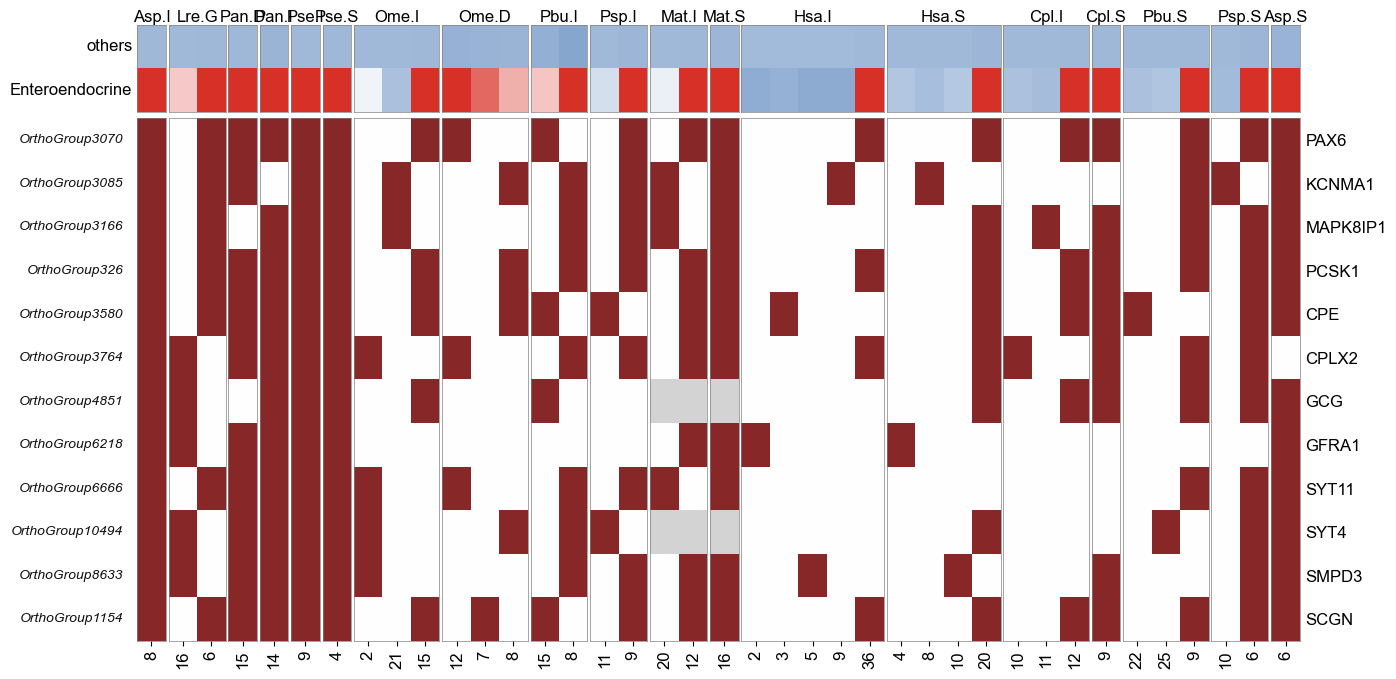

In [23]:
#1.ECC 节点298
conserved_genes = [
    'OrthoGroup3070', 'OrthoGroup3085', 'OrthoGroup3166', 'OrthoGroup326', 'OrthoGroup3580', 'OrthoGroup3764', 'OrthoGroup4851', 
    'OrthoGroup6218', 'OrthoGroup6666', 'OrthoGroup10494', 'OrthoGroup8633', 'OrthoGroup1154'
]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
target_modules_dic = {
    'Lre.G':['6'],  
    'Cpl.I':['12'], 'Cpl.S':['9'],  
    'Pse.I':['9'], 'Pse.S':['4'],  
    'Psp.I':['9'], 'Psp.S':['6'],  
    'Asp.I':['8'], 'Asp.S':['6'],  
    'Pbu.I':['8'], 'Pbu.S':['9'],  
    'Mat.I':['12'], 'Mat.S':['16'],  
    'Ome.I':['15'], 'Ome.D':['8','7'],  
    'Pan.I':['14'], 'Pan.D':['15'],  
    'Hsa.I':['36'], 'Hsa.S':['20'],  
}
celltype_mapper = {  
    'Enteroendocrine': 'Enteroendocrine',  
}  
  
draw_order = [  
    'Asp.I','Lre.G','Pan.D','Pan.I','Pse.I','Pse.S','Ome.I','Ome.D','Pbu.I','Psp.I','Mat.I','Mat.S','Hsa.I','Hsa.S','Cpl.I','Cpl.S','Pbu.S','Psp.S','Asp.S'  
]  
  
fig = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species,  
    target_modules_dic=target_modules_dic,  
  
    figuresize=(15, 8),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/EEC_ortho_paralogue_heatmap.node298.pdf',  
)  

  [PARA] OrthoGroup2614: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup30: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3070: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3085: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3166: 4 paralogue(

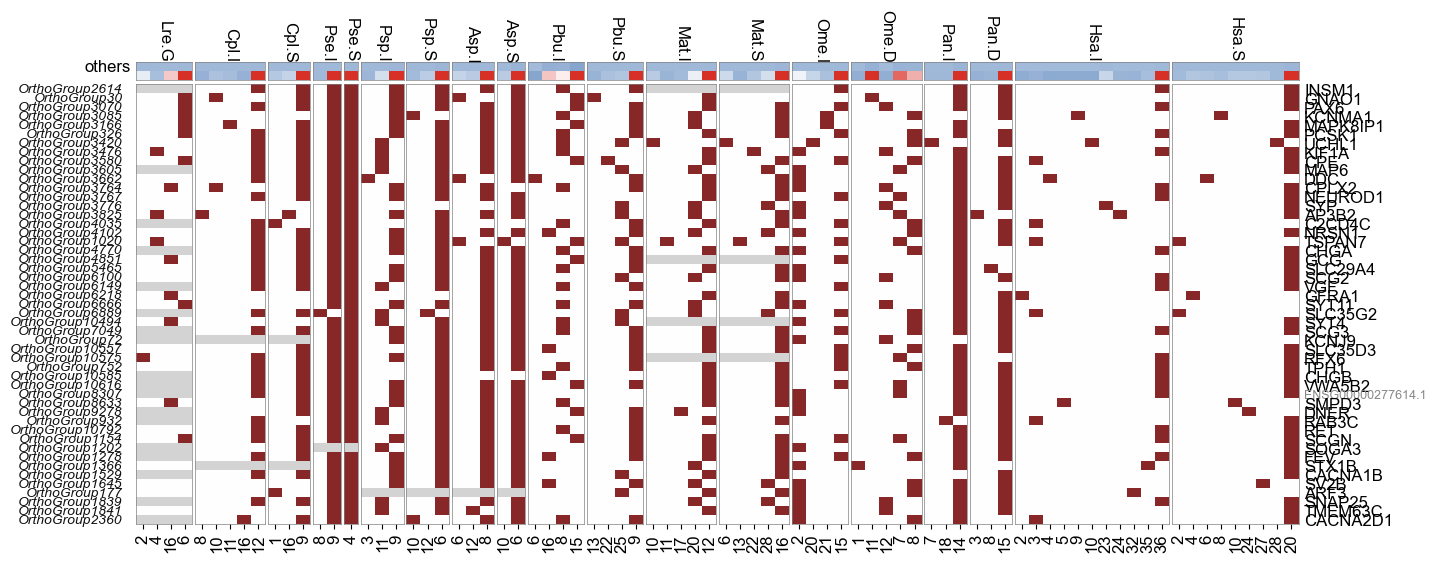

In [67]:
#1.ECC 节点300
conserved_genes = [
    'OrthoGroup2614', 'OrthoGroup30', 'OrthoGroup3070', 'OrthoGroup3085', 'OrthoGroup3166', 'OrthoGroup326', 'OrthoGroup3420', 'OrthoGroup3476', 'OrthoGroup3580', 
    'OrthoGroup3605', 'OrthoGroup3662', 'OrthoGroup3764', 'OrthoGroup3767', 'OrthoGroup3776', 'OrthoGroup3825', 'OrthoGroup4035', 'OrthoGroup4102', 'OrthoGroup1020', 
    'OrthoGroup4770', 'OrthoGroup4851', 'OrthoGroup5465','OrthoGroup6100', 'OrthoGroup6149', 'OrthoGroup6218', 'OrthoGroup6666', 'OrthoGroup6889', 'OrthoGroup10494', 
    'OrthoGroup7049', 'OrthoGroup72', 'OrthoGroup10557', 'OrthoGroup10575', 'OrthoGroup752', 'OrthoGroup10585', 'OrthoGroup10616', 'OrthoGroup8307', 'OrthoGroup8633', 'OrthoGroup9278', 
    'OrthoGroup932', 'OrthoGroup10792', 'OrthoGroup1154', 'OrthoGroup1202', 'OrthoGroup1278', 'OrthoGroup1366', 'OrthoGroup1529', 'OrthoGroup1645', 'OrthoGroup177', 'OrthoGroup1839', 
    'OrthoGroup1841', 'OrthoGroup2360',
    #  'ATP6V1G2', 
]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
target_modules_dic = {
    'Lre.G':['6'],  
    'Cpl.I':['12'], 'Cpl.S':['9'],  
    'Pse.I':['9'], 'Pse.S':['4'],  
    'Psp.I':['9'], 'Psp.S':['6'],  
    'Asp.I':['8'], 'Asp.S':['6'],  
    'Pbu.I':['15','8'], 'Pbu.S':['9'],  
    'Mat.I':['12'], 'Mat.S':['16'],  
    'Ome.I':['15'], 'Ome.D':['7','12','8'],  
    'Pan.I':['14'], 'Pan.D':['15'],  
    'Hsa.I':['36'], 'Hsa.S':['20'],  
}
celltype_mapper = {  
    'Enteroendocrine': 'Enteroendocrine',  
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'  
]  
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species,  
    target_modules_dic=target_modules_dic,
  
    figuresize=(15, 6),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270, 
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/EEC_ortho_paralogue_heatmap.node300.pdf',  
)  

In [42]:
# ── Step 1: 构建二值矩阵 ──  
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)



✅ 二值矩阵构建完成: 49/49 个基因至少在1个dataset中表达


In [43]:
binary_df[binary_df['human_gene'] == 'VWA5B2']

,Lre.G,Cpl.I,Cpl.S,Pse.I,Pse.S,Psp.I,Psp.S,Asp.I,Asp.S,Pbu.I,Pbu.S,Mat.I,Mat.S,Ome.I,Ome.D,Pan.I,Pan.D,Hsa.I,Hsa.S,human_gene
33,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,VWA5B2


✅ 二值矩阵构建完成: 49/49 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 49 个基因
   b组表达物种数范围: 4 ~ 9
   a组表达物种数范围: 2 ~ 10
📊 有值区域:
   Y轴 (group_a): 2 ~ 10
   X轴 (group_b): 4 ~ 9
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_enteroendocrine.pdf


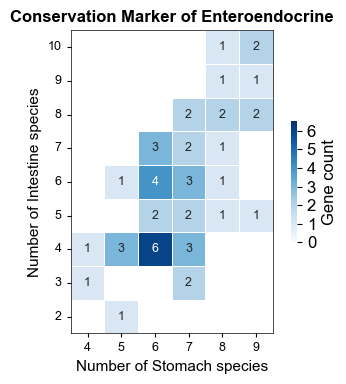

In [44]:
# ── Step 1: 构建二值矩阵 ──  
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
Intestine = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
Stomach = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=Intestine,  
    group_b=Stomach, 
    figsize=(4, 4),
    title="Enteroendocrine",  
    xlabel_name="Number of Stomach species",  
    ylabel_name="Number of Intestine species",  
    output_dir="conservation_enteroendocrine.pdf"  
) 

In [45]:
sorted_data = drawdata.sort_values(by=['Stomach_count', 'Intestine_count'],ascending=[False, False])

print(sorted_data)

                 gene  Stomach_count  Intestine_count
2                PAX6              9               10
5               PCSK1              9               10
27               SCG3              9                9
31               TPH1              9                8
41                FEV              9                8
29            SLC35D3              9                5
39               SCGN              8               10
33             VWA5B2              8                9
8                 CPE              8                8
18               CHGA              8                8
11              CPLX2              8                7
21               SCG2              8                6
16              NRSN1              8                5
0               INSM1              7                8
12            NEUROD1              7                8
20            SLC29A4              7                7
34  ENSG00000277614.1              7                7
4            MAPK8IP1       

✅ 图片已保存: ./Allcelltype_test2/EEC_upset.pdf


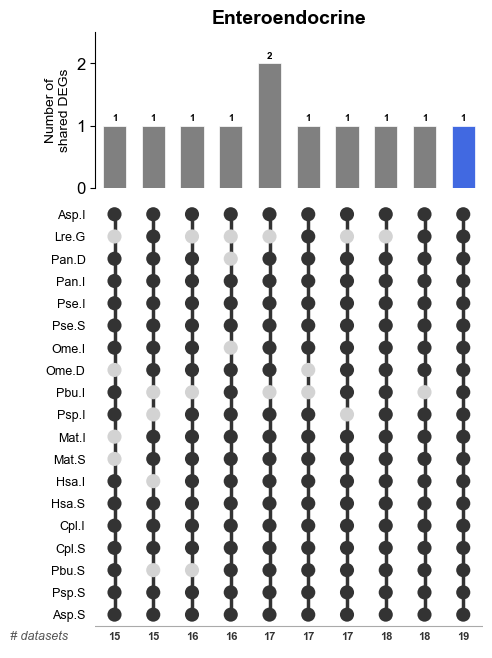

In [52]:
pattern_counts = plot_upset_enhanced(  
    binary_df,   
    data_cols,   
    target_modules_dic,  
    cell_type_name="Enteroendocrine",  
    min_count=1,  
    max_patterns=10,           # 最多显示25种模式  
    highlight_top_n=1,         # 高亮最大的1个模式  
    highlight_color='#4169E1', # 蓝色高亮  
    normal_color='#808080',    # 灰色  
    dataset_order=draw_order,  
    figsize=(5, 8),
    save_path="./Allcelltype_test2/EEC_upset.pdf"  
)

In [ ]:
# 遍历字典，只打印 human 列
for key, para_info in ortho_para_dic.items():
    # 取出 human 基因（你的结构里就是这么存的）
    human_gene = para_info.get('human', None)
    
    # 只打印有值的 human 基因
    if human_gene is not None:
        print(f"OrthoGroup {key} -> human: {human_gene}")


OrthoGroup OrthoGroup1278 -> human: orthologue    FEV
Name: human, dtype: object
OrthoGroup OrthoGroup8307 -> human: orthologue     ENSG00000277614.1
paralogue_1                 SCG5
paralogue_2    ENSG00000281931.1
Name: human, dtype: object
OrthoGroup OrthoGroup6218 -> human: orthologue     GFRA1
paralogue_1       NA
Name: human, dtype: object
OrthoGroup OrthoGroup752 -> human: orthologue     TPH1
paralogue_1      NA
paralogue_2      NA
paralogue_3      NA
Name: human, dtype: object
OrthoGroup OrthoGroup10792 -> human: orthologue    RET
Name: human, dtype: object
OrthoGroup OrthoGroup323 -> human: orthologue     PCSK2
paralogue_1       NA
Name: human, dtype: object
OrthoGroup OrthoGroup3085 -> human: orthologue     KCNMA1
paralogue_1        NA
Name: human, dtype: object
OrthoGroup OrthoGroup72 -> human: orthologue    KCNJ9
Name: human, dtype: object
OrthoGroup OrthoGroup7049 -> human: orthologue     SCG3
paralogue_1      NA
Name: human, dtype: object
OrthoGroup OrthoGroup3767 -> huma

  [PARA] OrthoGroup3575: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark']
  [PARA] OrthoGroup4559: 3 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup10226: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup10232: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup499: 2 paralogue(s), species=['alligator_gar', 'freshwa

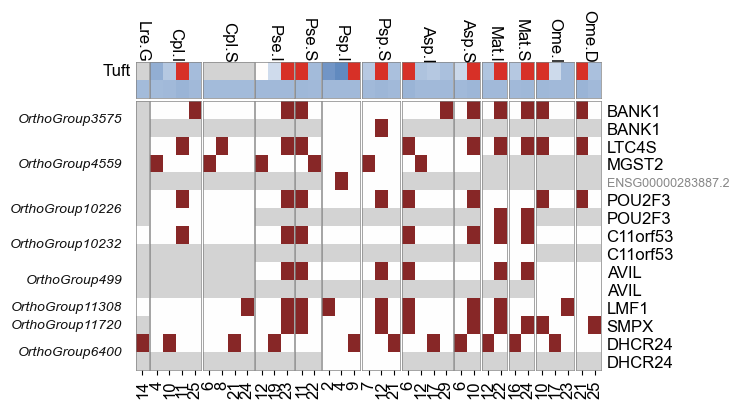

In [ ]:
#2.Tuft 节点  287
conserved_genes = [ 
    'OrthoGroup3575', 'OrthoGroup4559', 'OrthoGroup10226', 'OrthoGroup10232', 'OrthoGroup499', 'OrthoGroup11308', 'OrthoGroup11720',
]
target_modules_dic = {  
    'Lre.G':['9'],
    'Cpl.I':['11'],
    'Pse.I':['23'],
    'Pse.S':['11'],
    'Psp.S':['12'],
    'Asp.I':['6'],
    'Asp.S':['10'],
    'Mat.I':['22'],
    'Mat.S':['24'],
    'Ome.I':['10'],
    'Ome.D':['21'],
    'Pan.I': ['5'],

    'Pbu.S': ['29'],
    # 'Hsa.I': ['10'],
    # 'Psp.I': ['10'],

} 
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Tuft':'Tuft',
    'Mucous':'Tuft'  
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S', 'Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Mat.I','Mat.S','Ome.I','Ome.D',
    # 'Mat.I', 'Mat.S', 'Pse.S', 'Pse.I', 'Ome.I', 'Cpl.I','Asp.I', 'Asp.S',  'Psp.S'
]  
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species,  
    # target_modules_dic=target_modules_dic,
  
    figuresize=(6, 4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270,
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/Tuft_ortho_paralogue_heatmap.node287.pdf',  
)  

✅ 二值矩阵构建完成: 9/13 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (6 datasets): ['Cpl.S', 'Pse.S', 'Psp.S', 'Asp.S', 'Mat.S', 'Ome.D']
   a组 (7 datasets): ['Lre.G', 'Cpl.I', 'Pse.I', 'Psp.I', 'Asp.I', 'Mat.I', 'Ome.I']
   共 9 个基因
   b组表达物种数范围: 1 ~ 4
   a组表达物种数范围: 0 ~ 5
📊 有值区域:
   Y轴 (group_a): 0 ~ 5
   X轴 (group_b): 1 ~ 4
📏 使用固定尺寸: (3, 3)
✅ 图片已保存: conservation_Tuft_4.20.pdf


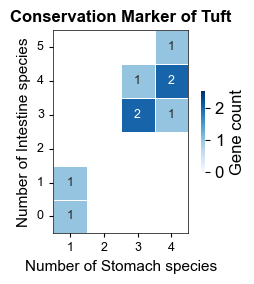

In [30]:
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
 
b = ['Lre.G','Cpl.I','Pse.I','Psp.I','Asp.I','Mat.I','Ome.I']  
a = ['Cpl.S', 'Pse.S','Psp.S','Asp.S','Mat.S','Ome.D']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(3, 3),
    title="Tuft",  
    xlabel_name="Number of Stomach species",  
    ylabel_name="Number of Intestine species",  
    output_dir="conservation_Tuft_4.20.pdf"  
) 

In [31]:
binary_df

,Lre.G,Cpl.I,Cpl.S,Pse.I,Pse.S,Psp.I,Psp.S,Asp.I,Asp.S,Mat.I,Mat.S,Ome.I,Ome.D,human_gene
0,0,0,0,1,1,0,0,0,1,1,1,1,1,BANK1
1,0,0,0,0,0,0,1,0,0,0,0,0,0,BANK1
2,0,1,0,1,1,0,0,1,1,1,1,1,1,LTC4S
3,0,1,0,1,1,0,1,1,1,0,0,1,1,POU2F3
4,0,0,0,0,0,0,0,0,0,1,1,0,0,POU2F3
5,0,1,0,1,1,0,0,1,1,1,1,0,0,C11orf53
6,0,0,0,1,1,0,1,1,0,1,1,0,0,AVIL
7,0,0,0,1,1,0,1,1,1,1,0,0,0,LMF1
8,0,0,0,1,1,0,1,1,1,1,1,1,0,SMPX


In [40]:
drawdata_sorted = drawdata.sort_values(by='count_b', ascending=False)

drawdata_sorted

,gene,count_b,count_a
0,BANK1,5,3
2,POU2F3,5,5
1,LTC4S,4,5
6,SMPX,4,4
3,C11orf53,3,4
4,AVIL,3,3
5,LMF1,3,3


  [PARA] OrthoGroup6400: 3 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup1008: 2 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup8544: 2 paralogue(s), species=['alligator_gar', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup817: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup1383: 3 paralog

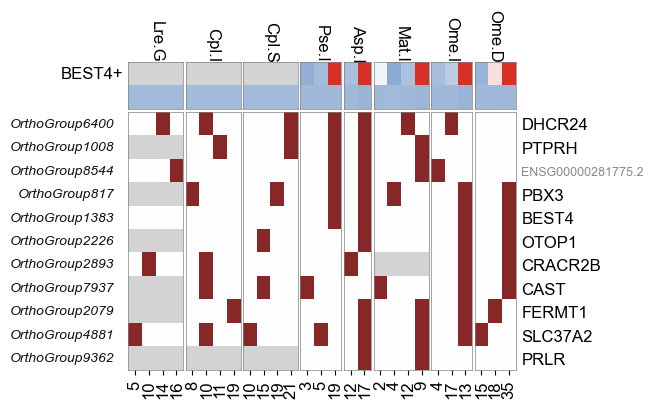

In [42]:
#3. BEST4 节点240
conserved_genes = [ 
    'OrthoGroup6400','OrthoGroup1008','OrthoGroup8544','OrthoGroup817','OrthoGroup1383',#'FAM3D', 
    #237 --> 238
    'OrthoGroup2226', 'OrthoGroup2893', 'OrthoGroup7937',
    #240 --> 241
    'OrthoGroup2079', 'OrthoGroup4881', 'OrthoGroup9362',
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'BEST4+':'BEST4+',
    'BEST4-like':'BEST4+',  
}  
  
draw_order = [  
    # 'Lre.G','Cpl.I','Cpl.S', 'Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Mat.I','Mat.S','Ome.I','Ome.D','Pbu.I'
    # 'Lre.G','Cpl.I','Cpl.S','Pse.I','Asp.I','Ome.D'
    # 'Mat.I', 'Asp.I', 'Pse.I', 'Pbu.I', 'Ome.D', 'Ome.I', 'Hsa.S', 'Hsa.I', 'Pan.I'
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Asp.I','Mat.I','Ome.I','Ome.D',
]  
target_modules_dic = {
    'Mat.I':['9'],
    'Asp.I':['17'],
    'Pse.I':['19'],
    'Pbu.I':['10'],
    'Ome.D':['35'],
    'Ome.I':['13'],
    'Hsa.S':['12','10'],
    'Hsa.I':['19'],
    'Pan.I':['5'],
    }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(5, 4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270,
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/BEST4_ortho_paralogue_heatmap.node240.pdf',  
)  

✅ 二值矩阵构建完成: 11/11 个基因至少在1个dataset中表达

基因在不同物种中表达的物种数统计（降序）:
human_gene
PBX3                 4
BEST4                4
PTPRH                3
ENSG00000281775.2    3
OTOP1                3
FERMT1               3
SLC37A2              3
DHCR24               2
CRACR2B              2
CAST                 2
PRLR                 2
dtype: int64
2    4
3    5
4    2
Name: count, dtype: int64


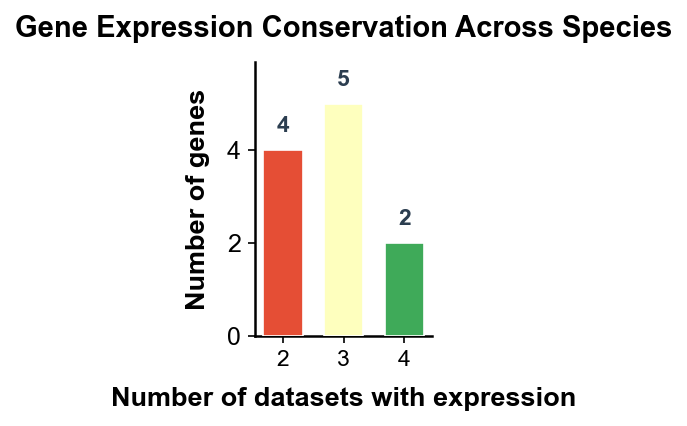

In [43]:
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
count = ['Lre.G','Pse.I','Asp.I','Mat.I','Ome.I','Ome.D']
df_sub = binary_df[count + ['human_gene']].set_index('human_gene')  
  
gene_species_count = df_sub[count].sum(axis=1)  
sorted_series = gene_species_count.sort_values(ascending=False)
print("\n基因在不同物种中表达的物种数统计（降序）:")
print(sorted_series)
species_gene_count = gene_species_count.value_counts().sort_index()  
species_gene_count = species_gene_count.reindex(range(1, len(count)+1), fill_value=0)  
  
# 过滤掉基因数为0的物种数  
species_gene_count = species_gene_count[species_gene_count > 0]  
  
print(species_gene_count)  
  
# ============================================================  
# 垂直柱状图：x = 物种数，y = 基因数  
# ============================================================  
fig, ax = plt.subplots(figsize=(2, 3), dpi=150)  
fig.patch.set_facecolor('white')  
  
x = species_gene_count.index.astype(int)  
y = species_gene_count.values.astype(int)  
  
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(x)))  
  
bars = ax.bar(x, y, color=colors, edgecolor='white',  
              linewidth=0.8, width=0.65, zorder=3)  
  
# 柱顶数值标签  
for bar, val in zip(bars, y):  
    ax.text(bar.get_x() + bar.get_width() / 2,  
            bar.get_height() + 0.3,  
            str(int(val)),  
            ha='center', va='bottom',  
            fontsize=11, fontweight='bold', color='#2C3E50')  
  
# ============================================================  
# 坐标轴设置  
# ============================================================  
ax.set_xticks(x)  
ax.set_xticklabels([str(i) for i in x], fontsize=11)  
ax.set_xlabel('Number of datasets with expression',  
              fontsize=13, fontweight='bold', labelpad=8)  
ax.set_ylabel('Number of genes',  
              fontsize=13, fontweight='bold', labelpad=8)  
ax.set_title('Gene Expression Conservation Across Species',  
             fontsize=14, fontweight='bold', pad=12)  
  
ax.set_ylim(0, max(y) * 1.18)  
  
# ✅ 去掉网格线  
ax.yaxis.grid(False)  
ax.xaxis.grid(False)  
  
ax.spines[['top', 'right']].set_visible(False)  
ax.spines[['left', 'bottom']].set_linewidth(1.2)  
  
plt.tight_layout()  
plt.savefig('gene_conservation_BEST4_barplot.pdf', dpi=300, bbox_inches='tight')  
plt.show()  

  [PARA] OrthoGroup1008: 2 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup6400: 3 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup817: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup8544: 2 paralogue(s), species=['alligator_gar', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup1383: 3 paralog

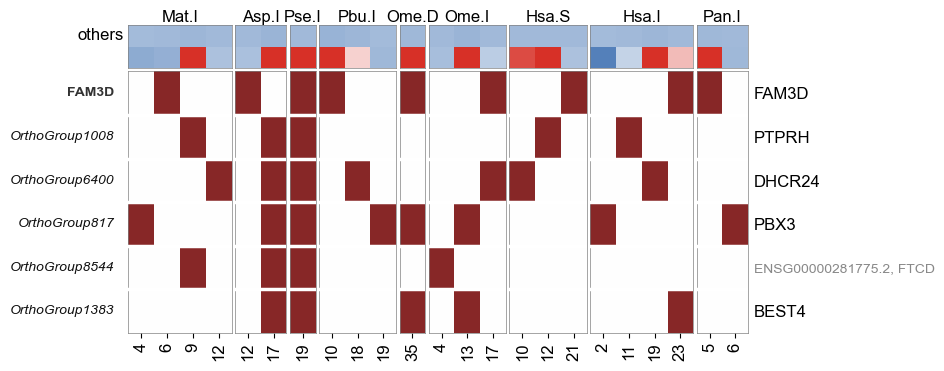

In [29]:
#4. B cells 节点298
conserved_genes = [ 
    'OrthoGroup1008', 'OrthoGroup6400', 'OrthoGroup817', 'OrthoGroup8544', 'FAM3D', 'OrthoGroup1383'
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'BEST4+':'BEST4+',
    'BEST4-like':'BEST4+',  
}  
  
draw_order = [  
    #'Lre.G','Cpl.I','Cpl.S','Pse.I','Asp.I','Ome.D'
    'Mat.I', 'Asp.I', 'Pse.I', 'Pbu.I', 'Ome.D', 'Ome.I', 'Hsa.S', 'Hsa.I', 'Pan.I'
]  
target_modules_dic = {
    'Mat.I':['9'],
    'Asp.I':['17'],
    'Pse.I':['19'],
    'Pbu.I':['10'],
    'Ome.D':['35'],
    'Ome.I':['13'],
    'Hsa.S':['12','10'],
    'Hsa.I':['19'],
    'Pan.I':['5'],
    }
  
fig = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(8, 4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/BEST4_ortho_paralogue_heatmap.node240.pdf',  
)  

  [PARA] OrthoGroup2728: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3346: 6 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3800: 4 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup7508: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup7848: 2 paralogue(s), spe

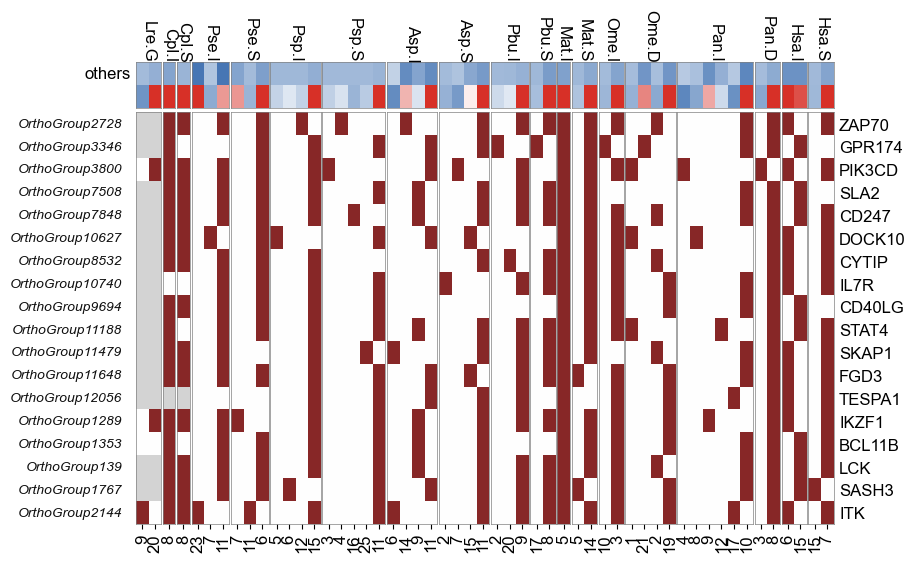

In [51]:
#5. T cells 节点 334
conserved_genes = [ 
    'OrthoGroup2728', 'OrthoGroup3346', 'OrthoGroup3800', 'OrthoGroup7508', 'OrthoGroup7848', 'OrthoGroup10627', 'OrthoGroup8532', 'OrthoGroup10740', 'OrthoGroup9694', 'OrthoGroup11188', 
    'OrthoGroup11479', 'OrthoGroup11648', 'OrthoGroup12056', 'OrthoGroup1289', 'OrthoGroup1353', 'OrthoGroup139', 'OrthoGroup1767', 'OrthoGroup2144'
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    "T cells":'T',
    'T-like':'T',
    'T and NK cells':'T',
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'
]
target_modules_dic = {
    'Mat.S':['14'],
    'Mat.I':['5'],
    'Pbu.I':['9'],
    'Pbu.S':['8'],
    'Asp.S':['11'],
    'Asp.I':['9','11'],
    'Pse.S':['6'],
    'Pse.I':['11','7'],
    'Ome.I':['3'],
    'Ome.D':['2','19'],
    'Cpl.S':['8'],
    'Cpl.I':['8'],
    'Psp.I':['15'],
    'Psp.S':['11'],
    'Hsa.I':['15','6'],
    'Hsa.S':['7'],
    'Pan.D':['8'],
    'Pan.I':['10'],
    'Lre.G':['20'],
        }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(9,6),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270, 
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/T_ortho.node334.pdf',  
)  

✅ 二值矩阵构建完成: 18/18 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 18 个基因
   b组表达物种数范围: 4 ~ 9
   a组表达物种数范围: 6 ~ 9
📊 有值区域:
   Y轴 (group_a): 6 ~ 9
   X轴 (group_b): 4 ~ 9
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_T_cells.pdf


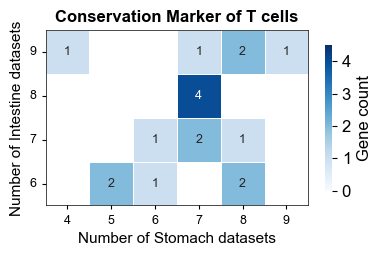

In [53]:
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="T cells",  
    xlabel_name="Number of Stomach datasets",  
    ylabel_name="Number of Intestine datasets",  
    output_dir="conservation_T_cells.pdf"  
)

  [PARA] OrthoGroup10588: 2 paralogue(s), species=['alligator_gar', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup10759: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'zebrafish']
  [PARA] OrthoGroup10907: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup1132: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup11416: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfi

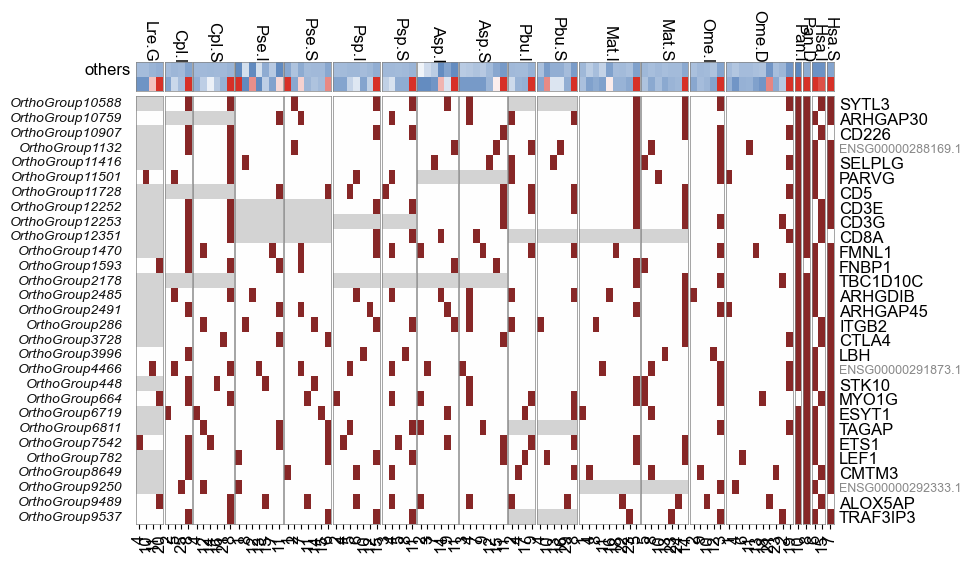

In [68]:
#5. T cells Pan
conserved_genes = [ 
'OrthoGroup10588', 'OrthoGroup10759', 'OrthoGroup10907', 'OrthoGroup1132', 'OrthoGroup11416', 'OrthoGroup11501', 'OrthoGroup11728', 'OrthoGroup12252', 'OrthoGroup12253', 'OrthoGroup12351', 'OrthoGroup1470', 'OrthoGroup1593', 'OrthoGroup2178', 'OrthoGroup2485', 'OrthoGroup2491', 'OrthoGroup286', 'OrthoGroup3728', 'OrthoGroup3996', 'OrthoGroup4466', 'OrthoGroup448', 'OrthoGroup664', 'OrthoGroup6719', 'OrthoGroup6811', 'OrthoGroup7542', 'OrthoGroup782', 'OrthoGroup8649', 'OrthoGroup9250', 'OrthoGroup9489', 'OrthoGroup9537'
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    "T cells":'T',
    'T-like':'T',
    'T and NK cells':'T',
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'
]
target_modules_dic = {
    'Mat.S':['14'],
    'Mat.I':['5'],
    'Pbu.I':['9'],
    'Pbu.S':['8'],
    'Asp.S':['11'],
    'Asp.I':['9','11'],
    'Pse.S':['6'],
    'Pse.I':['11','7'],
    'Ome.I':['3'],
    'Ome.D':['2','19'],
    'Cpl.S':['8'],
    'Cpl.I':['8'],
    'Psp.I':['15'],
    'Psp.S':['11'],
    'Hsa.I':['15','6'],
    'Hsa.S':['7'],
    'Pan.D':['8'],
    'Pan.I':['10'],
    'Lre.G':['20'],
        }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(9,6),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270, 
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/T_ortho.hsa_pan.pdf',  
)  

  [PARA] OrthoGroup2616: 3 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup2956: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup2965: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup354: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] Orth

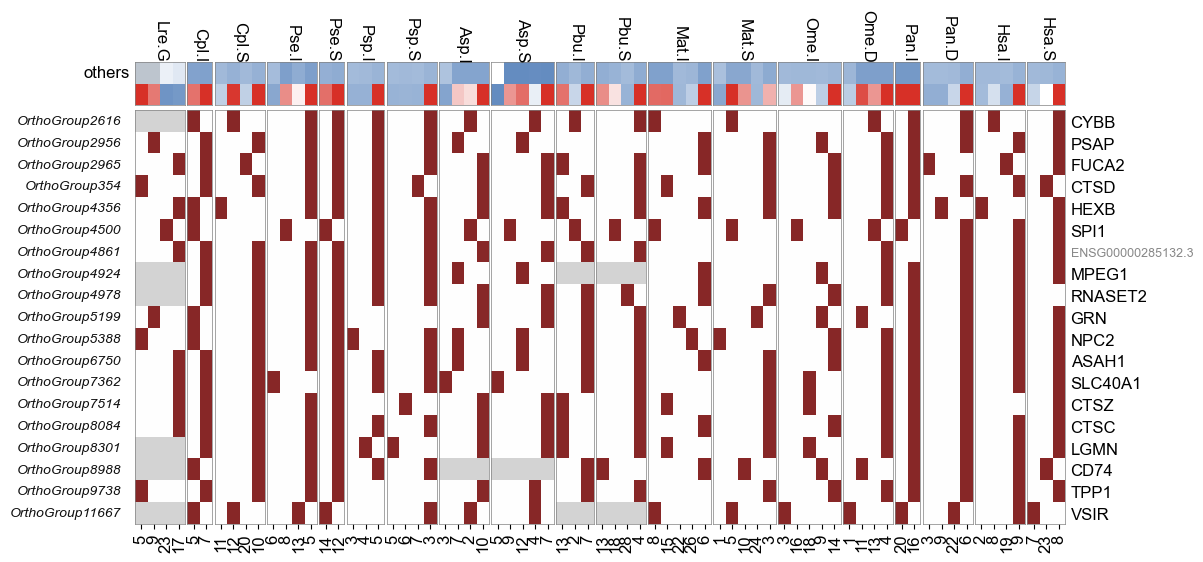

In [54]:
#6. Myeloid 节点 351
conserved_genes = [ 
    'OrthoGroup2616', 'OrthoGroup2956', 'OrthoGroup2965', 'OrthoGroup354', 'OrthoGroup4356', 'OrthoGroup4500', 'OrthoGroup4861', 'OrthoGroup4924', 'OrthoGroup4978', 'OrthoGroup5199', 
    'OrthoGroup5388', 'OrthoGroup6750', 'OrthoGroup7362', 'OrthoGroup7514', 'OrthoGroup8084', 'OrthoGroup8301', 'OrthoGroup8988', 'OrthoGroup9738', 'OrthoGroup11667', 
    # 'HLA-DQA1''ATP6V1B2', 
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Myeloid':'Myeloid',
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'
]  
target_modules_dic = {
    'Hsa.I':['9'],
    'Hsa.S':['8'],
    'Pse.S':['12'],
    'Cpl.I':['7','5'],
    'Cpl.S':['10'],
    'Pan.I':['16'],
    'Asp.I':['10','2'],
    'Asp.S':['12','7','4'],
    'Mat.I':['6'],
    'Mat.S':['3'],
    'Psp.I':['5'],
    'Psp.S':['3'],
    'Ome.D':['4'],
    'Ome.I':['14','9'],
    'Pbu.I':['7','2'],
    'Pbu.S':['4'],
    'Pan.D':['6'],
    'Pse.I':['5'],
    'Lre.G':['17'],
            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(12,6),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270,
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/Myeloid_ortho.node351.pdf',  
)  

✅ 二值矩阵构建完成: 19/19 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 19 个基因
   b组表达物种数范围: 2 ~ 9
   a组表达物种数范围: 3 ~ 9
📊 有值区域:
   Y轴 (group_a): 3 ~ 9
   X轴 (group_b): 2 ~ 9
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_Myeloid.pdf


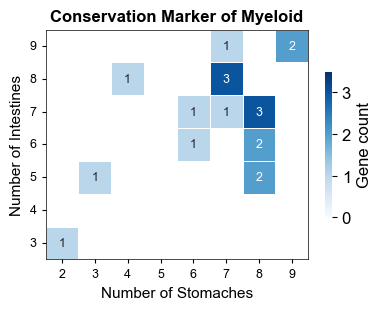

In [55]:
# ── Step 1: 构建二值矩阵 ──  
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="Myeloid",  
    xlabel_name="Number of Stomaches",  
    ylabel_name="Number of Intestines",      
    output_dir="conservation_Myeloid.pdf"  
) 

  [PARA] OrthoGroup2682: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup2929: 1 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'zebrafish']
  [PARA] OrthoGroup305: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3101: 6 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3109: 6 paralogue(s), species=['alligator_gar', 

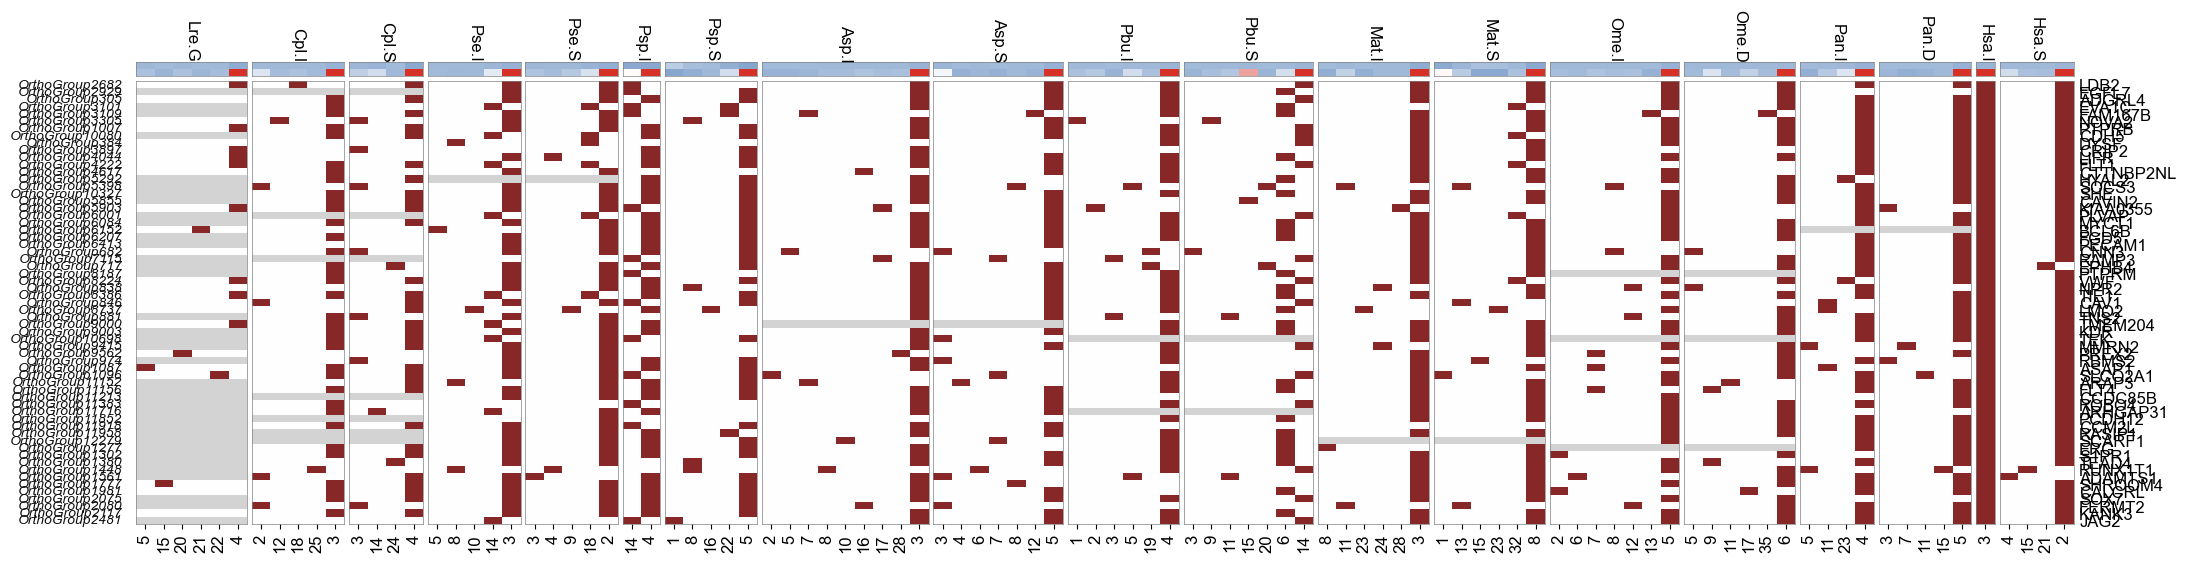

✅ 二值矩阵构建完成: 61/61 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 61 个基因
   b组表达物种数范围: 3 ~ 9
   a组表达物种数范围: 4 ~ 10
📊 有值区域:
   Y轴 (group_a): 4 ~ 10
   X轴 (group_b): 3 ~ 9
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_Endothelial.pdf


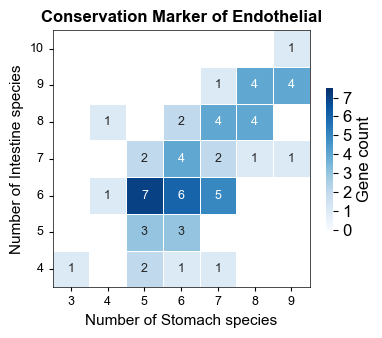

In [56]:
#7. Endothelial 节点 370
conserved_genes = [ 
    'OrthoGroup2682', 'OrthoGroup2929', 'OrthoGroup305', 'OrthoGroup3101', 'OrthoGroup3109','OrthoGroup3305', 'OrthoGroup1007', 'OrthoGroup10080', 'OrthoGroup384', 
    'OrthoGroup3897', 'OrthoGroup4044', 'OrthoGroup4222', 'OrthoGroup4617', 'OrthoGroup5292', 'OrthoGroup5398', 'OrthoGroup10327', 'OrthoGroup5855', 'OrthoGroup5903', 
    'OrthoGroup6001', 'OrthoGroup6084', 'OrthoGroup6152', 'OrthoGroup6207', 'OrthoGroup6413', 'OrthoGroup682', 'OrthoGroup7115', 'OrthoGroup717', 'OrthoGroup8187', 
    'OrthoGroup8224', 'OrthoGroup838', 'OrthoGroup8386', 'OrthoGroup846', 'OrthoGroup8737', 'OrthoGroup881', 'OrthoGroup9000', 'OrthoGroup9003', 'OrthoGroup10698', 
    'OrthoGroup9415', 'OrthoGroup9562', 'OrthoGroup974', 'OrthoGroup1087', 'OrthoGroup1096', 'OrthoGroup11152', 'OrthoGroup11156', 'OrthoGroup11213', 'OrthoGroup11383', 
    'OrthoGroup11716', 'OrthoGroup11852', 'OrthoGroup11918', 'OrthoGroup11958', 'OrthoGroup12279', 'OrthoGroup1277', 'OrthoGroup1302', 'OrthoGroup1380', 'OrthoGroup1448', 
    'OrthoGroup1561', 'OrthoGroup1777', 'OrthoGroup1981', 'OrthoGroup2075', 'OrthoGroup2080', 'OrthoGroup2117', 'OrthoGroup2481',
    # 'NOTCH4', 
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Endothelial':'Endothelial',
    'Lymphatic_endothelia':'Endothelial',
    'Vascular_endothelia':'Endothelial',
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'
]
target_modules_dic = {
    "Pse.I":['3'],
    "Pse.S":['2'],
    "Lre.G":['4'],
    "Cpl.S":['4'],
    "Cpl.I":['3'],
    "Asp.I":['3'],
    "Asp.S":['5'],
    "Psp.I":['4'],
    "Psp.S":['5'],
    "Pan.D":['5'],
    "Pan.I":['4'],
    "Mat.I":['3'],
    "Mat.S":['8'],
    "Pbu.S":['14','6'],
    "Pbu.I":['4'],
    "Ome.I":['5'],
    "Ome.D":['6'],
    "Hsa.I":['3'],
    "Hsa.S":['2'],
            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 

    figuresize=(25,6),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270, 
    
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/Endothelial_ortho.node370.pdf',  
)  

binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="Endothelial",  
    xlabel_name="Number of Stomach species",  
    ylabel_name="Number of Intestine species",  
    output_dir="conservation_Endothelial.pdf"  
) 

In [42]:
sorted_data = drawdata.sort_values(by='count_b', ascending=False)

print(sorted_data.to_string(index=False))

     gene  count_b  count_a
    PTPRB       10        8
      SHE        9        9
    KANK3        9        9
   ADGRL4        9        8
     TIE1        9        8
      VWF        9        7
      KDR        9        8
     LIFR        9        7
     FGD5        9        8
    MYCT1        9        9
     FLT4        8        8
    EPHB4        8        6
  TMEM204        8        7
   RASIP1        8        7
    RBMS2        8        4
   CAVIN2        8        8
     LDB2        8        7
     FLT1        8        5
     CDH5        8        6
  SHROOM4        8        7
     SOX7        8        7
    S1PR1        7        9
      ERG        7        7
    HYAL2        7        7
CTTNBP2NL        7        5
    TEAD4        7        6
  SLCO2A1        7        5
    PTPRM        7        6
   CALCRL        7        8
    ROBO4        7        5
    PLVAP        7        4
    ARAP3        6        7
   NOTCH4        6        4
  CCDC85B        6        6
 ARHGAP31        6  

  [PARA] OrthoGroup3244: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3290: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3342: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3519: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3681: 2 paralogue(s), species=['

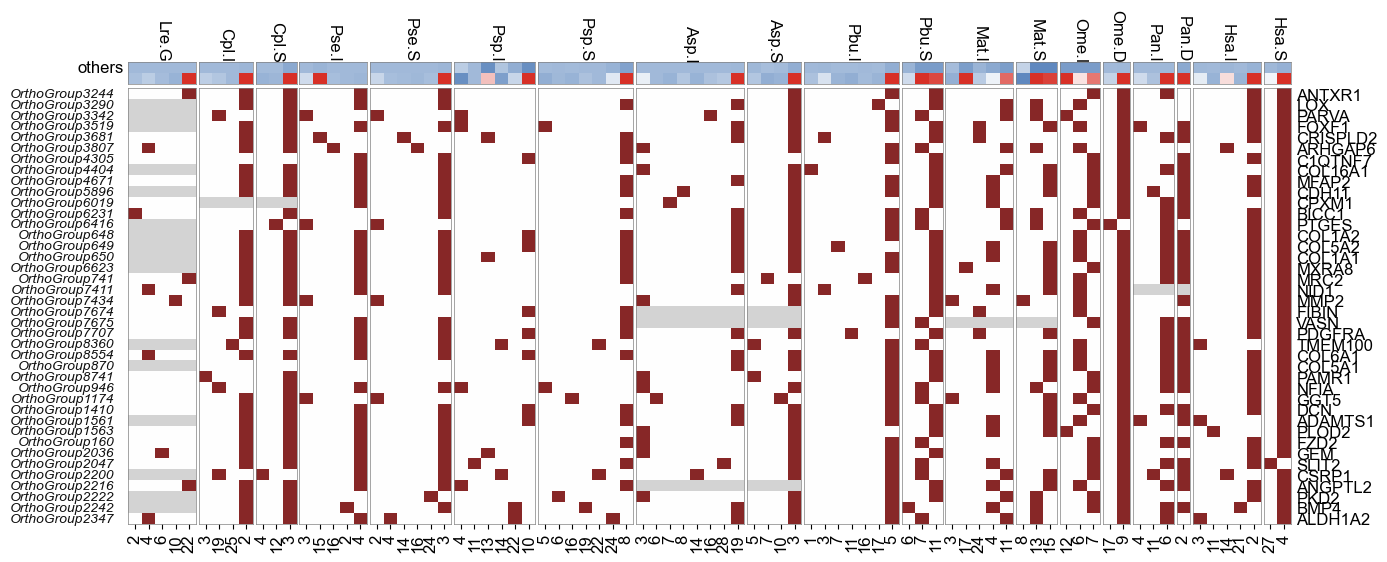

In [57]:
#8. Mesenchymal 节点 398
conserved_genes = [ 
    'OrthoGroup3244', 'OrthoGroup3290', 'OrthoGroup3342', 'OrthoGroup3519', 'OrthoGroup3681', 'OrthoGroup3807', 'OrthoGroup4305', 'OrthoGroup4404', 'OrthoGroup4671', 'OrthoGroup5896', 
    'OrthoGroup6019', 'OrthoGroup6231', 'OrthoGroup6416', 'OrthoGroup648', 'OrthoGroup649', 'OrthoGroup650', 'OrthoGroup6623', 'OrthoGroup741', 'OrthoGroup7411', 'OrthoGroup7434', 
    'OrthoGroup7674', 'OrthoGroup7675', 'OrthoGroup7707', 'OrthoGroup8360', 'OrthoGroup8554', 'OrthoGroup870', 'OrthoGroup8741', 'OrthoGroup946', 'OrthoGroup1174', 'OrthoGroup1410', 
    'OrthoGroup1561', 'OrthoGroup1563', 'OrthoGroup160', 'OrthoGroup2036', 'OrthoGroup2047', 'OrthoGroup2200', 'OrthoGroup2216', 'OrthoGroup2222', 'OrthoGroup2242', 'OrthoGroup2347'
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Mesenchymal':'Mesenchymal',
    'Smooth_muscle':'Mesenchymal',
    'Pericyte':'Mesenchymal',
    'Myofibroblast':'Mesenchymal',
    'Fibroblast':'Mesenchymal',
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'
]
target_modules_dic = {
    "Asp.S":['3'],
    "Asp.I":['19'],
    "Ome.I":['6','7'],
    "Pse.I":['2','4'],
    "Lre.G":['22'],
    "Pse.S":['3'],
    "Mat.I":['4','11'],
    "Mat.S":['13','15'],
    "Pan.D":['2'],
    "Pan.I":['6'],
    "Cpl.S":['3'],
    "Cpl.I":['2'],
    "Psp.S":['8'],
    "Psp.I":['10'],
    "Pbu.I":['5'],
    "Pbu.S":['7','11'],
    "Ome.D":['9'],
    "Hsa.S":['4'],
    "Hsa.I":['2'],
            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(15,6),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270,
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/Mesenchymal_ortho.node398.pdf',  
)  

✅ 二值矩阵构建完成: 40/40 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 40 个基因
   b组表达物种数范围: 4 ~ 9
   a组表达物种数范围: 3 ~ 9
📊 有值区域:
   Y轴 (group_a): 3 ~ 9
   X轴 (group_b): 4 ~ 9
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_Mesenchymal.pdf


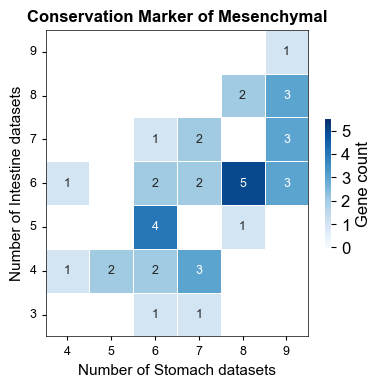

In [58]:
# ── Step 1: 构建二值矩阵 ──  
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="Mesenchymal",  
    xlabel_name="Number of Stomach datasets",  
    ylabel_name="Number of Intestine datasets",      
    output_dir="conservation_Mesenchymal.pdf"  
) 

  [PARA] OrthoGroup2628: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup2629: 5 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup10023: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3586: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup3617:

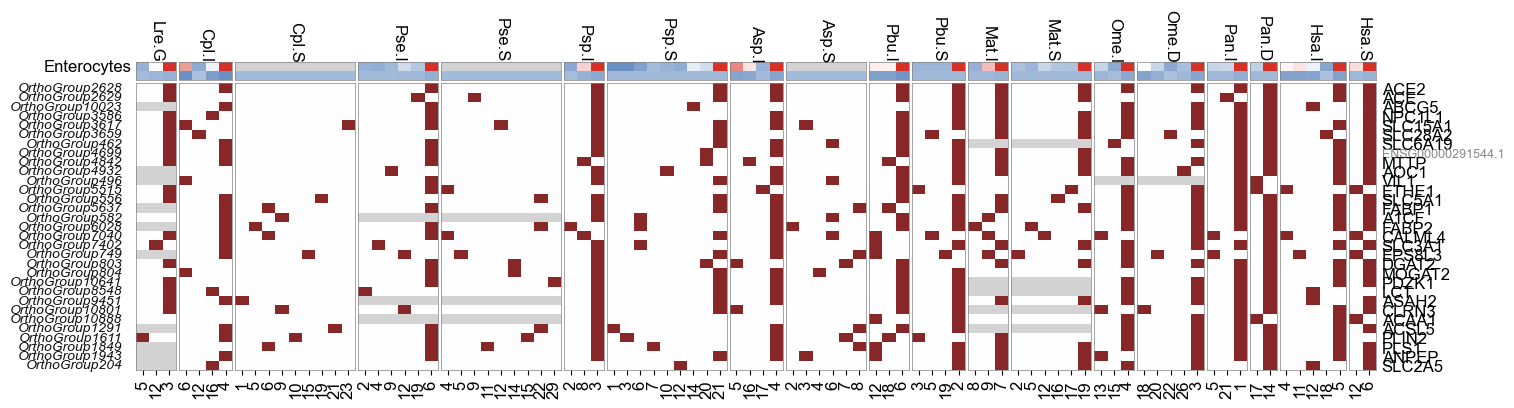

In [49]:
#9. Enterocytes 节点217 测试218节点的效果
conserved_genes = [ 
    # 'OrthoGroup2628', 'OrthoGroup2629','OrthoGroup3617', 'OrthoGroup462', 'OrthoGroup4699', 'OrthoGroup4842', 'OrthoGroup4932', 'OrthoGroup496', 'OrthoGroup5515', 
    # 'OrthoGroup556', 'OrthoGroup5637', 'OrthoGroup582', 'OrthoGroup6028', 'OrthoGroup7040', 'OrthoGroup7402', 'OrthoGroup803', 'OrthoGroup804', 'OrthoGroup10641', 'OrthoGroup10801', 
    # 'OrthoGroup10888', 'OrthoGroup1291', 'OrthoGroup1611', 'OrthoGroup1849', 'OrthoGroup1943',
    # 'MGAM', 'NDRG1', 

    'OrthoGroup2628', 'OrthoGroup2629', 'OrthoGroup10023', 'OrthoGroup3586', 'OrthoGroup3617', 'OrthoGroup3659', 
    'OrthoGroup462', 'OrthoGroup4699', 'OrthoGroup4842', 'OrthoGroup4932', 'OrthoGroup496', 'OrthoGroup5515', 'OrthoGroup556', 'OrthoGroup5637', 
    'OrthoGroup582', 'OrthoGroup6028', 'OrthoGroup7040', 'OrthoGroup7402', 'OrthoGroup749', 'OrthoGroup803', 'OrthoGroup804', 'OrthoGroup10641', 
    'OrthoGroup8548', 'OrthoGroup9451', 'OrthoGroup10801', 'OrthoGroup10888', 'OrthoGroup1291', 'OrthoGroup1611', 'OrthoGroup1849', 'OrthoGroup1943', 
    'OrthoGroup204'
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Enterocytes-like':'Enterocytes',
    'Enterocytes':'Enterocytes'
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'
]
target_modules_dic = {
    "Pan.I":['1'],
    "Cpl.I":['4'],
    "Pse.I":['6'],
    "Lre.G":['3'],
    "Mat.S":['19'],
    "Mat.I":['7'],
    "Pbu.S":['2'],
    "Pbu.I":['6'],
    "Asp.I":['4'],
    "Psp.S":['21'],
    "Psp.I":['3'],
    "Ome.I":['4'],
    "Ome.D":['3'],
    "Hsa.I":['5'],
    "Hsa.S":['6'],
    "Pan.D":['14'],
            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(16,4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270,
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/Enterocytes_ortho.node.217.pdf',  
)  

✅ 二值矩阵构建完成: 31/31 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 31 个基因
   b组表达物种数范围: 1 ~ 6
   a组表达物种数范围: 2 ~ 10
📊 有值区域:
   Y轴 (group_a): 2 ~ 10
   X轴 (group_b): 1 ~ 6
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_Enterocytes.pdf


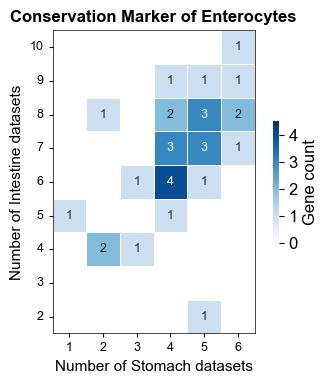

                 gene  count_b  count_a
0                ACE2        6       10
29              ANPEP        6        7
4             SLC15A1        6        9
23              ASAH2        6        8
13              FABP1        6        8
12             SLC5A1        5        9
28               PLS1        5        7
21              PDZK1        5        8
17             SLC3A1        5        7
1                 ACE        5        6
30             SLC2A5        5        2
6             SLC6A19        5        8
3              NPC1L1        5        8
8                MTTP        5        7
20             MOGAT2        4        6
2               ABCG5        4        6
26              ACSL5        4        8
24              CLRN3        4        5
5             SLC28A2        4        6
22                LCT        4        6
15              FABP2        4        7
19              DGAT2        4        8
7   ENSG00000291544.1        4        9
14               A1CF        4        7


In [31]:
# ── Step 1: 构建二值矩阵 ──  
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="Enterocytes",  
    xlabel_name="Number of Stomach datasets",  
    ylabel_name="Number of Intestine datasets",      
    output_dir="conservation_Enterocytes.pdf"  
) 
sorted_data = drawdata.sort_values(by='count_b', ascending=False)
print(sorted_data)
print(drawheatmap)

  [PARA] OrthoGroup2796: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'zebrafish']
  [PARA] OrthoGroup3434: 5 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup386: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup4056: 3 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup8421: 2 paralogue(s), species=['alligator_gar', 

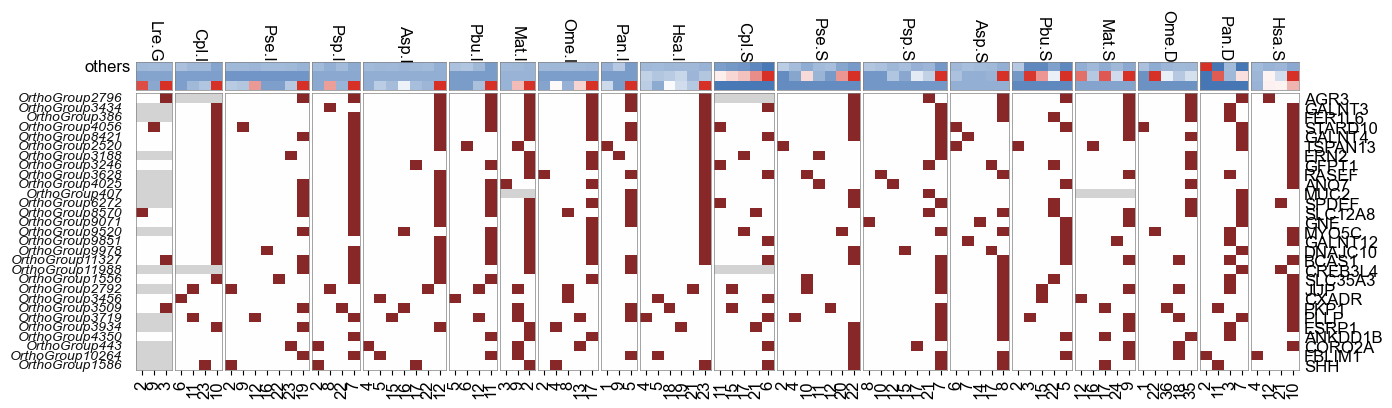

In [59]:
#10. Goblet Mucus节点 
conserved_genes = [ 
    'OrthoGroup2796', 'OrthoGroup3434', 'OrthoGroup386', 'OrthoGroup4056', 'OrthoGroup8421', # commone genes
    'OrthoGroup2520', 'OrthoGroup3188', 'OrthoGroup3246','OrthoGroup3628', 'OrthoGroup4025', 'OrthoGroup407', 'OrthoGroup6272','OrthoGroup8570', 'OrthoGroup9071', 'OrthoGroup9520', 'OrthoGroup9851', 'OrthoGroup9978', 'OrthoGroup11327', 'OrthoGroup11988', 'OrthoGroup1556', #Goblet specific genes # 'FAM3D'
    'OrthoGroup2792', 'OrthoGroup3456', 'OrthoGroup3509', 'OrthoGroup3719', 'OrthoGroup3934','OrthoGroup4350', 'OrthoGroup443', 'OrthoGroup10264','OrthoGroup11327', 'OrthoGroup1586' # Mucus specific genes #'SYT8', 
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Goblet':'Goblet',
    'Goblet-like':'Goblet' , 
    'Mucus':'Mucus',
    'Foveolar':'Mucus',
    'Mucus-like':'Mucus', 
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Pse.I','Psp.I','Asp.I','Pbu.I','Mat.I','Ome.I','Pan.I','Hsa.I','Cpl.S','Pse.S','Psp.S','Asp.S','Pbu.S','Mat.S','Ome.D','Pan.D','Hsa.S',
]
target_modules_dic = {
    'Lre.G':['3'],
    'Cpl.I':['10'],
    'Pse.I':['19'],
    'Psp.I':['7'],
    'Asp.I':['12'],
    'Pbu.I':['11'],
    'Mat.I':['2'],
    'Ome.I':['17'],
    'Pan.I':['5'],
    'Hsa.I':['23'],
    'Cpl.S':['6'],
    'Pse.S':['22'],
    'Psp.S':['7'],
    'Asp.S':['8'],
    'Pbu.S':['5'],
    'Mat.S':['9'],
    'Ome.D':['18','35'],
    'Pan.D':['3','7'],
    'Hsa.S':['10'],
            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(15,4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270,
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/Goblet_and_Mucus_ortho.node.pdf',  
)  

✅ 二值矩阵构建完成: 29/29 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 29 个基因
   b组表达物种数范围: 2 ~ 9
   a组表达物种数范围: 0 ~ 10
📊 有值区域:
   Y轴 (group_a): 0 ~ 10
   X轴 (group_b): 2 ~ 9
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_Goblet_Mucus.pdf


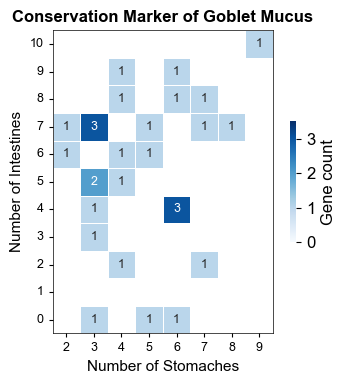

In [60]:
# ── Step 1: 构建二值矩阵 ──  
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="Goblet Mucus",  
    xlabel_name="Number of Stomaches",  
    ylabel_name="Number of Intestines",      
    output_dir="conservation_Goblet_Mucus.pdf"  
) 

  [PARA] OrthoGroup2796: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'zebrafish']
  [PARA] OrthoGroup3434: 5 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup386: 4 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup4056: 3 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup8421: 2 paralogue(s), species=['alligator_gar', 

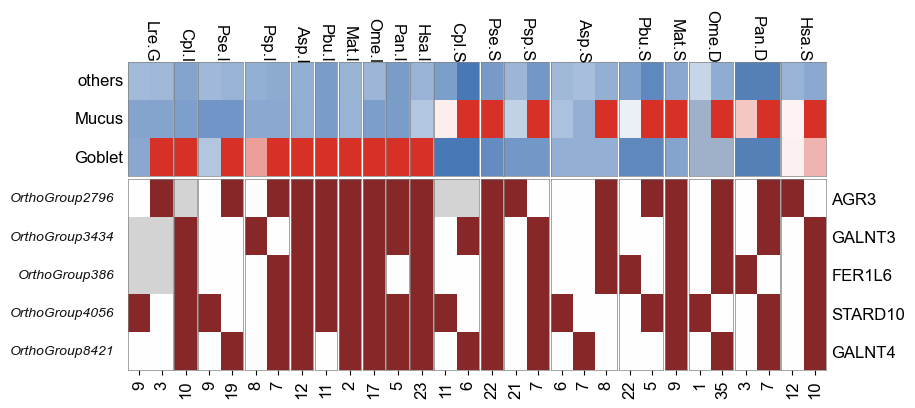

In [65]:
#10. Goblet Mucus节点 
conserved_genes = [ 
    'OrthoGroup2796', 'OrthoGroup3434', 'OrthoGroup386', 'OrthoGroup4056', 'OrthoGroup8421', # commone genes
    # 'OrthoGroup2520', 'OrthoGroup3188', 'OrthoGroup3246','OrthoGroup3628', 'OrthoGroup4025', 'OrthoGroup407', 'OrthoGroup6272','OrthoGroup8570', 'OrthoGroup9071', 'OrthoGroup9520', 'OrthoGroup9851', 'OrthoGroup9978', 'OrthoGroup11327', 'OrthoGroup11988', 'OrthoGroup1556', #Goblet specific genes # 'FAM3D'
    # 'OrthoGroup2792', 'OrthoGroup3456', 'OrthoGroup3509', 'OrthoGroup3719', 'OrthoGroup3934','OrthoGroup4350', 'OrthoGroup443', 'OrthoGroup10264','OrthoGroup11327', 'OrthoGroup1586' # Mucus specific genes #'SYT8', 
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Goblet':'Goblet',
    'Goblet-like':'Goblet' , 
    'Mucus':'Mucus',
    'Foveolar':'Mucus',
    'Mucus-like':'Mucus', 
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Pse.I','Psp.I','Asp.I','Pbu.I','Mat.I','Ome.I','Pan.I','Hsa.I','Cpl.S','Pse.S','Psp.S','Asp.S','Pbu.S','Mat.S','Ome.D','Pan.D','Hsa.S',
]
target_modules_dic = {
    'Lre.G':['3'],
    'Cpl.I':['10'],
    'Pse.I':['19'],
    'Psp.I':['7'],
    'Asp.I':['12'],
    'Pbu.I':['11'],
    'Mat.I':['2'],
    'Ome.I':['17'],
    'Pan.I':['5'],
    'Hsa.I':['23'],
    'Cpl.S':['6'],
    'Pse.S':['22'],
    'Psp.S':['7'],
    'Asp.S':['8'],
    'Pbu.S':['5'],
    'Mat.S':['9'],
    'Ome.D':['35'],
    'Pan.D':['7'],
    'Hsa.S':['10'],
            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(9,4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270,
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',  
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    # save='./Allcelltype_test2/Goblet_and_Mucus_ortho.node.pdf',  
)  

✅ 二值矩阵构建完成: 5/5 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (10 datasets): ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']
   共 5 个基因
   b组表达物种数范围: 6 ~ 8
   a组表达物种数范围: 7 ~ 9
📊 有值区域:
   Y轴 (group_a): 7 ~ 9
   X轴 (group_b): 6 ~ 8
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_common specific.pdf


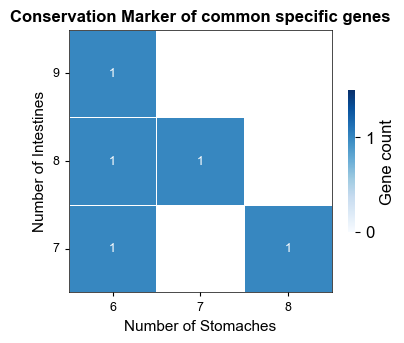

In [66]:
# ── Step 1: 构建二值矩阵 ──  
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="common specific genes",  
    xlabel_name="Number of Stomaches",  
    ylabel_name="Number of Intestines",      
    output_dir="conservation_common specific.pdf"  
) 

  [PARA] OrthoGroup5249: 3 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup7223: 2 paralogue(s), species=['alligator_gar', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup8197: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup7365: 2 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup8537: 2

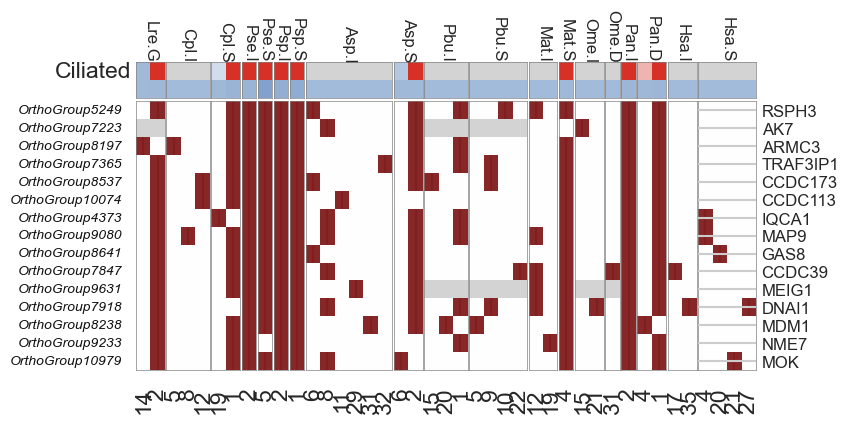

In [197]:
#11. Ciliated 节点 265
# conserved_genes = [ 
#     'OrthoGroup2868', 'OrthoGroup3445', 'OrthoGroup3446', 'OrthoGroup10040', 'OrthoGroup10074', 'OrthoGroup4101', 'OrthoGroup4122', 'OrthoGroup4154', 'OrthoGroup4179', 
#     'OrthoGroup10162', 'OrthoGroup4304', 'OrthoGroup4373', 'OrthoGroup4387', 'OrthoGroup4508', 'OrthoGroup4555', 'OrthoGroup4602', 'OrthoGroup10196', 'OrthoGroup4651', 'OrthoGroup4717', 
#     'OrthoGroup4737', 'OrthoGroup4925', 'OrthoGroup4968', 'OrthoGroup4976', 'OrthoGroup5058', 'OrthoGroup5223', 'OrthoGroup5249', 'OrthoGroup1029', 'OrthoGroup5279', 'OrthoGroup10292', 
#     'OrthoGroup5297', 'OrthoGroup5350', 'OrthoGroup5356', 'OrthoGroup10305', 'OrthoGroup10323', 'OrthoGroup5548', 'OrthoGroup5585', 'OrthoGroup5592', 'OrthoGroup5650', 'OrthoGroup5666', 
#     'OrthoGroup5701', 'OrthoGroup5727', 'OrthoGroup5794', 'OrthoGroup5806', 'OrthoGroup5834', 'OrthoGroup5905', 'OrthoGroup5910', 'OrthoGroup5934', 'OrthoGroup5967', 'OrthoGroup6133', 
#     'OrthoGroup6134', 'OrthoGroup6187', 'OrthoGroup6258', 'OrthoGroup6279', 'OrthoGroup6326', 'OrthoGroup6339', 'OrthoGroup6352', 'OrthoGroup6370', 'OrthoGroup6424', 'OrthoGroup10459', 
#     'OrthoGroup6717', 'OrthoGroup6725', 'OrthoGroup6776', 'OrthoGroup6786', 'OrthoGroup6823', 'OrthoGroup6995', 'OrthoGroup7005', 'OrthoGroup7075', 'OrthoGroup7186', 'OrthoGroup7223', 
#     'OrthoGroup7228', 'OrthoGroup7236', 'OrthoGroup7314', 'OrthoGroup7319', 'OrthoGroup7341', 'OrthoGroup7365', 'OrthoGroup7366', 'OrthoGroup10577', 'OrthoGroup7471', 'OrthoGroup7567', 
#     'OrthoGroup7580', 'OrthoGroup7615', 'OrthoGroup10596', 'OrthoGroup7696', 'OrthoGroup7746', 'OrthoGroup7798', 'OrthoGroup10607', 'OrthoGroup7822', 'OrthoGroup7833', 'OrthoGroup7847', 
#     'OrthoGroup10612', 'OrthoGroup7908', 'OrthoGroup7918', 'OrthoGroup7928', 'OrthoGroup8006', 'OrthoGroup10617', 'OrthoGroup8036', 'OrthoGroup10623', 'OrthoGroup8122', 'OrthoGroup8174', 
#     'OrthoGroup8179', 'OrthoGroup8196', 'OrthoGroup8197', 'OrthoGroup8209', 'OrthoGroup8238', 'OrthoGroup8270', 'OrthoGroup8390', 'OrthoGroup10631', 'OrthoGroup8456', 'OrthoGroup8537', 
#     'OrthoGroup8575', 'OrthoGroup8588', 'OrthoGroup10647', 'OrthoGroup8634', 'OrthoGroup8641', 'OrthoGroup8666', 'OrthoGroup8681', 'OrthoGroup8695', 'OrthoGroup8707', 'OrthoGroup8714', 
#     'OrthoGroup8792', 'OrthoGroup8797', 'OrthoGroup8816', 'OrthoGroup8826', 'OrthoGroup8846', 'OrthoGroup8867', 'OrthoGroup9053', 'OrthoGroup9080', 'OrthoGroup9084', 'OrthoGroup9115', 
#     'OrthoGroup9131', 'OrthoGroup9141', 'OrthoGroup9168', 'OrthoGroup9170', 'OrthoGroup9175', 'OrthoGroup9176', 'OrthoGroup9233', 'OrthoGroup9329', 'OrthoGroup10730', 'OrthoGroup9405', 
#     'OrthoGroup9416', 'OrthoGroup9438', 'OrthoGroup9518', 'OrthoGroup9546', 'OrthoGroup9608', 'OrthoGroup9631', 'OrthoGroup9635', 'OrthoGroup9683', 'OrthoGroup9747', 'OrthoGroup9812', 
#     'OrthoGroup9826', 'OrthoGroup9856', 'OrthoGroup9944', 'OrthoGroup9983', 'OrthoGroup10789', 'OrthoGroup10851', 'OrthoGroup10873', 'OrthoGroup10893', 'OrthoGroup109', 'OrthoGroup10937', 
#     'OrthoGroup10951', 'OrthoGroup10976', 'OrthoGroup10979', 'OrthoGroup110', 'OrthoGroup11026', 'OrthoGroup11044', 'OrthoGroup111', 'OrthoGroup11102', 'OrthoGroup11196', 'OrthoGroup112', 
#     'OrthoGroup11307', 'OrthoGroup11360', 'OrthoGroup114', 'OrthoGroup11404', 'OrthoGroup11462', 'OrthoGroup115', 'OrthoGroup11530', 'OrthoGroup11573', 'OrthoGroup11576', 'OrthoGroup116', 
#     'OrthoGroup11621', 'OrthoGroup11629', 'OrthoGroup11638', 'OrthoGroup11639', 'OrthoGroup11643', 'OrthoGroup11654', 'OrthoGroup11670', 'OrthoGroup11682', 'OrthoGroup11683', 
#     'OrthoGroup11690', 'OrthoGroup117', 'OrthoGroup11713', 'OrthoGroup11794', 'OrthoGroup11812', 'OrthoGroup11814', 'OrthoGroup11815', 'OrthoGroup11826', 'OrthoGroup11836', 
#     'OrthoGroup11863', 'OrthoGroup11882', 'OrthoGroup11893', 'OrthoGroup11905', 'OrthoGroup11917', 'OrthoGroup11920', 'OrthoGroup11936', 'OrthoGroup11938', 'OrthoGroup11939', 
#     'OrthoGroup11947', 'OrthoGroup11948', 'OrthoGroup11950', 'OrthoGroup11964', 'OrthoGroup12', 'OrthoGroup12053', 'OrthoGroup12061', 'OrthoGroup12079', 'OrthoGroup12101', 
#     'OrthoGroup12124', 'OrthoGroup12134', 'OrthoGroup12142', 'OrthoGroup12143', 'OrthoGroup12191', 'OrthoGroup12224', 'OrthoGroup12258', 'OrthoGroup12272', 'OrthoGroup12280', 
#     'OrthoGroup12325', 'OrthoGroup12339', 'OrthoGroup12345', 'OrthoGroup12366', 'OrthoGroup12394', 'OrthoGroup12425', 'OrthoGroup12446', 'OrthoGroup12448', 'OrthoGroup12542', 
#     'OrthoGroup12571', 'OrthoGroup14', 'OrthoGroup1888', 'OrthoGroup1889', 'OrthoGroup2126', 'OrthoGroup2325', 'OrthoGroup2430',
#     # 'MAPK15', 
#     ]

conserved_genes = [
    'OrthoGroup5249',  # RSPH3
    'OrthoGroup7223',  # AK7
    'OrthoGroup8197',  # ARMC3
    'OrthoGroup7365',  # TRAF3IP1
    'OrthoGroup8537',  # CCDC173
    'OrthoGroup10074', # CCDC113
    'OrthoGroup4373',  # IQCA1
    'OrthoGroup9080',  # MAP9
    'OrthoGroup8641',  # GAS8
    'OrthoGroup7847',  # CCDC39
    'OrthoGroup9631',  # MEIG1
    'OrthoGroup7918',  # DNAI1
    'OrthoGroup8238',  # MDM1
    'OrthoGroup9233',  # NME7
    'OrthoGroup10979'   # MOK
]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para    
)
celltype_mapper = {  
    'Ciliated':'Ciliated'
}  
  
draw_order = [  
    'Lre.G','Cpl.I','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.I','Asp.S','Pbu.I','Pbu.S','Mat.I','Mat.S','Ome.I','Ome.D','Pan.I','Pan.D','Hsa.I','Hsa.S'
]
target_modules_dic = {
    'Lre.G':['2'],
    # 'Cpl.I':[''],
    'Cpl.S':['1'],
    'Pse.I':['2'],
    'Pse.S':['5'],
    'Psp.I':['2'],
    'Psp.S':['1'],
    # 'Asp.I':[''],
    'Asp.S':['2'],
    'Pbu.I':['1'],
    # 'Pbu.S':[''],
    # 'Mat.I':[''],
    'Mat.S':['4'],
    # 'Ome.I':[''],
    # 'Ome.D':[''],
    'Pan.I':['2'],
    'Pan.D':['1'],
    # 'Hsa.I':[''],
    # 'Hsa.S':[''],
            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(8,4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True, 
    upper_title_rotation=270,  

    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',
      
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/Ciliated_ortho.node265.pdf',  
)  

In [189]:
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)

✅ 二值矩阵构建完成: 15/15 个基因至少在1个dataset中表达


In [190]:
binary_df 
count = ['Lre.G','Cpl.S','Pse.I','Pse.S','Psp.I','Psp.S','Asp.S','Mat.S','Pan.I','Pan.D']

8     2
9     6
10    7
Name: count, dtype: int64


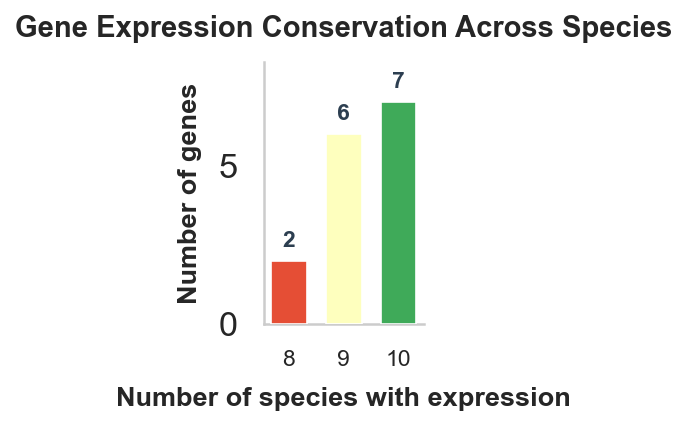

In [192]:
import pandas as pd  
import matplotlib.pyplot as plt  
import numpy as np  
  
df_sub = binary_df[count + ['human_gene']].set_index('human_gene')  
  
gene_species_count = df_sub[count].sum(axis=1)  
species_gene_count = gene_species_count.value_counts().sort_index()  
species_gene_count = species_gene_count.reindex(range(1, len(count)+1), fill_value=0)  
  
# 过滤掉基因数为0的物种数  
species_gene_count = species_gene_count[species_gene_count > 0]  
  
print(species_gene_count)  
  
# ============================================================  
# 垂直柱状图：x = 物种数，y = 基因数  
# ============================================================  
fig, ax = plt.subplots(figsize=(2, 3), dpi=150)  
fig.patch.set_facecolor('white')  
  
x = species_gene_count.index.astype(int)  
y = species_gene_count.values.astype(int)  
  
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(x)))  
  
bars = ax.bar(x, y, color=colors, edgecolor='white',  
              linewidth=0.8, width=0.65, zorder=3)  
  
# 柱顶数值标签  
for bar, val in zip(bars, y):  
    ax.text(bar.get_x() + bar.get_width() / 2,  
            bar.get_height() + 0.3,  
            str(int(val)),  
            ha='center', va='bottom',  
            fontsize=11, fontweight='bold', color='#2C3E50')  
  
# ============================================================  
# 坐标轴设置  
# ============================================================  
ax.set_xticks(x)  
ax.set_xticklabels([str(i) for i in x], fontsize=11)  
ax.set_xlabel('Number of species with expression',  
              fontsize=13, fontweight='bold', labelpad=8)  
ax.set_ylabel('Number of genes',  
              fontsize=13, fontweight='bold', labelpad=8)  
ax.set_title('Gene Expression Conservation Across Species',  
             fontsize=14, fontweight='bold', pad=12)  
  
ax.set_ylim(0, max(y) * 1.18)  
  
# ✅ 去掉网格线  
ax.yaxis.grid(False)  
ax.xaxis.grid(False)  
  
ax.spines[['top', 'right']].set_visible(False)  
ax.spines[['left', 'bottom']].set_linewidth(1.2)  
  
plt.tight_layout()  
plt.savefig('gene_conservation_ciliated_barplot.pdf', dpi=300, bbox_inches='tight')  
plt.show()  


  [PARA] OrthoGroup353: 5 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'mississippi_paddlefish', 'mouse', 'whitespotted_bambooshark']
  [PARA] OrthoGroup3561: 5 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'planarian', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup4203: 4 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup4773: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup5608: 2 paralogue(s), species=['alligator_gar

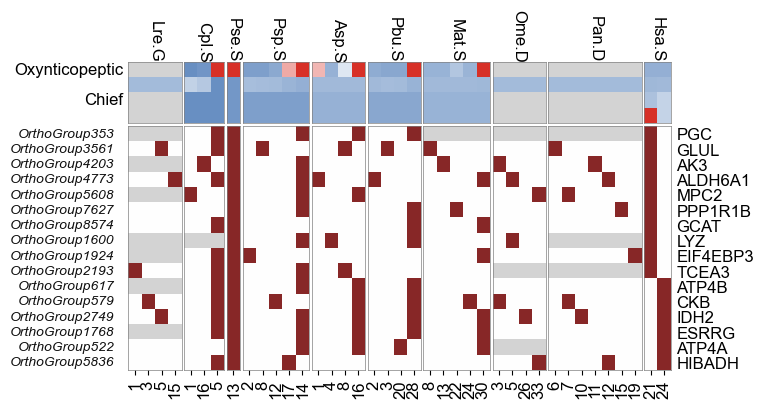

In [27]:
#12. Oxynticopeptic 节点 276
conserved_genes = [ 
    #main
    'OrthoGroup353', 'OrthoGroup3561', 'OrthoGroup4203', 'OrthoGroup4773', 'OrthoGroup5608', 'OrthoGroup7627', 'OrthoGroup8574', 'OrthoGroup1600', 'OrthoGroup1924', 'OrthoGroup2193',
    #instine specific
    'OrthoGroup617', 'OrthoGroup579', 'OrthoGroup2749', 'OrthoGroup1768', 'OrthoGroup522', 'OrthoGroup5836'
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Parietal':'Parietal',
    'Chief':'Chief',
    'Oxynticopeptic':'Oxynticopeptic',
}  
  
draw_order = [  
    'Lre.G','Cpl.S','Pse.S','Psp.S','Asp.S','Pbu.S','Mat.S','Ome.D','Pan.D','Hsa.S'
]
target_modules_dic = {
    # 'Lre.G':[''],
    'Cpl.S':['5'],
    'Pse.S':['13'],
    'Psp.S':['14'],
    'Asp.S':['16'],
    'Pbu.S':['28'],
    'Mat.S':['30'],
    # 'Ome.D':[''],
    # 'Pan.D':[''],
    'Hsa.S':['21','24'],

            }
  
fig,adata_list,expanded,boundaries,human_gene_map = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(7,4),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
    upper_title_rotation=270, 
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',
      
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/Oxynticopeptic_ortho.node276.pdf',  
)  

✅ 二值矩阵构建完成: 16/16 个基因至少在1个dataset中表达
✅ 统计完成:
   b组 (9 datasets): ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']
   a组 (1 datasets): ['Lre.G']
   共 16 个基因
   b组表达物种数范围: 3 ~ 7
   a组表达物种数范围: 0 ~ 0
📊 有值区域:
   Y轴 (group_a): 0 ~ 0
   X轴 (group_b): 3 ~ 7
📏 使用固定尺寸: (4, 4)
✅ 图片已保存: conservation_Goblet_Mucus.pdf


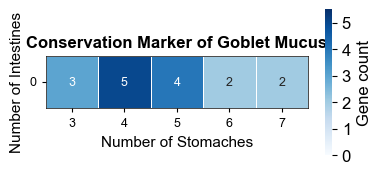

        gene  count_b  count_a
12      IDH2        7        0
13     ESRRG        7        0
0        PGC        6        0
10     ATP4B        6        0
3    ALDH6A1        5        0
6       GCAT        5        0
11       CKB        5        0
14     ATP4A        5        0
4       MPC2        4        0
5    PPP1R1B        4        0
7        LYZ        4        0
8   EIF4EBP3        4        0
9      TCEA3        4        0
1       GLUL        3        0
2        AK3        3        0
15    HIBADH        3        0
     0    1    2    3    4    5    6    7    8    9
0  0.0  0.0  0.0  3.0  5.0  4.0  2.0  2.0  0.0  0.0
1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [28]:
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)
b = ['Lre.G', 'Asp.I', 'Pan.I', 'Pse.I', 'Ome.I', 'Pbu.I', 'Psp.I', 'Mat.I', 'Hsa.I', 'Cpl.I']  
a = ['Pan.D', 'Pse.S', 'Ome.D', 'Mat.S', 'Hsa.S', 'Cpl.S', 'Pbu.S', 'Psp.S', 'Asp.S']  
  
drawdata, drawheatmap = draw_compare_from_binary(  
    binary_df,  
    group_a=b,  
    group_b=a, 
    figsize=(4, 4),
    title="Goblet Mucus",  
    xlabel_name="Number of Stomaches",  
    ylabel_name="Number of Intestines",      
    output_dir="conservation_Goblet_Mucus.pdf"  
) 
sorted_data = drawdata.sort_values(by='count_b', ascending=False)
print(sorted_data)
print(drawheatmap)

In [24]:
binary_df, data_cols = build_target_binary_matrix(
    adata_list, expanded,target_modules_dic,human_gene_map
)

✅ 二值矩阵构建完成: 16/16 个基因至少在1个dataset中表达


In [25]:
binary_df 
count = ['Lre.G','Cpl.S','Pse.S','Psp.S','Asp.S','Pbu.S','Mat.S','Ome.D','Pan.D','Hsa.S']

3    3
4    5
5    4
6    2
7    2
Name: count, dtype: int64


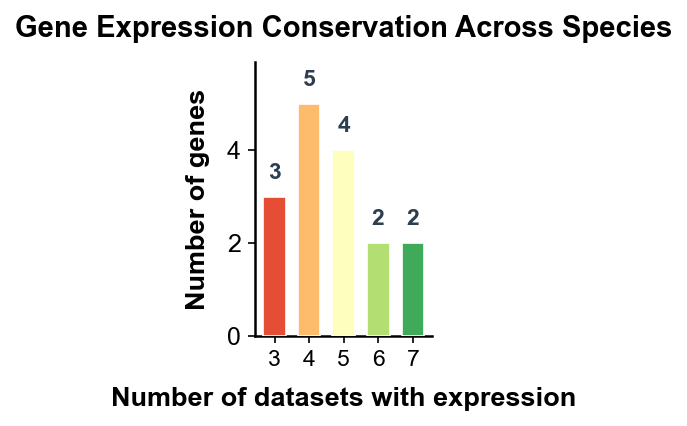

In [26]:
import pandas as pd  
import matplotlib.pyplot as plt  
import numpy as np  
  
df_sub = binary_df[count + ['human_gene']].set_index('human_gene')  
  
gene_species_count = df_sub[count].sum(axis=1)  
species_gene_count = gene_species_count.value_counts().sort_index()  
species_gene_count = species_gene_count.reindex(range(1, len(count)+1), fill_value=0)  
  
# 过滤掉基因数为0的物种数  
species_gene_count = species_gene_count[species_gene_count > 0]  
  
print(species_gene_count)  
  
# ============================================================  
# 垂直柱状图：x = 物种数，y = 基因数  
# ============================================================  
fig, ax = plt.subplots(figsize=(2, 3), dpi=150)  
fig.patch.set_facecolor('white')  
  
x = species_gene_count.index.astype(int)  
y = species_gene_count.values.astype(int)  
  
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(x)))  
  
bars = ax.bar(x, y, color=colors, edgecolor='white',  
              linewidth=0.8, width=0.65, zorder=3)  
  
# 柱顶数值标签  
for bar, val in zip(bars, y):  
    ax.text(bar.get_x() + bar.get_width() / 2,  
            bar.get_height() + 0.3,  
            str(int(val)),  
            ha='center', va='bottom',  
            fontsize=11, fontweight='bold', color='#2C3E50')  
  
# ============================================================  
# 坐标轴设置  
# ============================================================  
ax.set_xticks(x)  
ax.set_xticklabels([str(i) for i in x], fontsize=11)  
ax.set_xlabel('Number of datasets with expression',  
              fontsize=13, fontweight='bold', labelpad=8)  
ax.set_ylabel('Number of genes',  
              fontsize=13, fontweight='bold', labelpad=8)  
ax.set_title('Gene Expression Conservation Across Species',  
             fontsize=14, fontweight='bold', pad=12)  
  
ax.set_ylim(0, max(y) * 1.18)  
  
# ✅ 去掉网格线  
ax.yaxis.grid(False)  
ax.xaxis.grid(False)  
  
ax.spines[['top', 'right']].set_visible(False)  
ax.spines[['left', 'bottom']].set_linewidth(1.2)  
  
plt.tight_layout()  
plt.savefig('oxynticopeptic_gene_conservation_barplot.pdf', dpi=300, bbox_inches='tight')  
plt.show()  


  [PARA] OrthoGroup11761: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'human', 'indian_medaka', 'lampreyv2', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark']
  [PARA] OrthoGroup9162: 1 paralogue(s), species=['alligator_gar', 'fly', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup963: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup8169: 2 paralogue(s), species=['alligator_gar', 'freshwater_butterflyfish', 'gray_bichir', 'human', 'indian_medaka', 'lampreyv2', 'lungfish', 'mississippi_paddlefish', 'mouse', 'tarpon', 'whitespotted_bambooshark', 'zebrafish']
  [PARA] OrthoGroup2698: 5 paralogue(s), species=['alligat

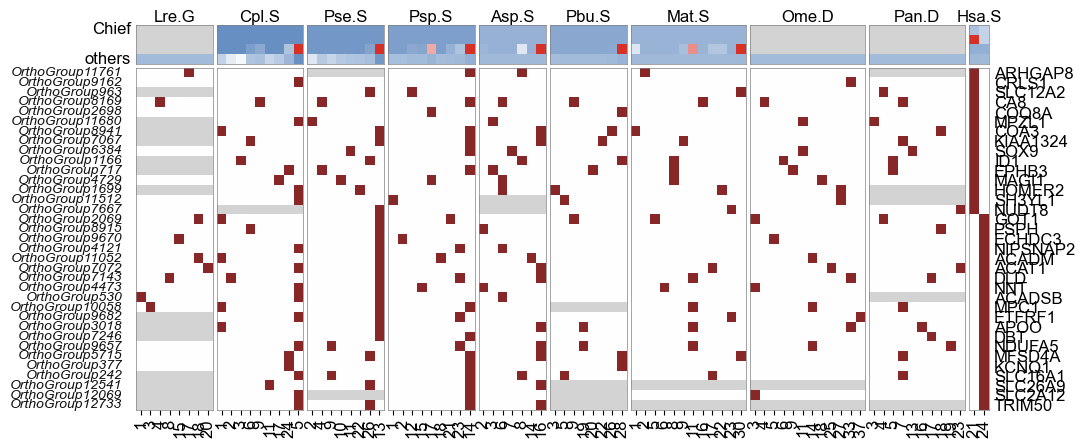

In [155]:
#12. Oxynticopeptic 节点 recruiment
conserved_genes = [ 
    'OrthoGroup11761','OrthoGroup9162', 'OrthoGroup963','OrthoGroup8169', 'OrthoGroup2698', 'OrthoGroup11680', 'OrthoGroup8941', 'OrthoGroup7067','OrthoGroup8941', 'OrthoGroup7067',
    'OrthoGroup6384','OrthoGroup1166', 'OrthoGroup717', 'OrthoGroup4729', 'OrthoGroup1699', 'OrthoGroup11512','OrthoGroup7667',
     
    'OrthoGroup2069', 'OrthoGroup8915',  'OrthoGroup9670',  'OrthoGroup4121', 'OrthoGroup11052', 'OrthoGroup7072','OrthoGroup7143', 'OrthoGroup4473', 'OrthoGroup530',
    'OrthoGroup10058', 'OrthoGroup9682', 'OrthoGroup3018', 'OrthoGroup7246', 
    'OrthoGroup9657', 'OrthoGroup5715', 'OrthoGroup377', 'OrthoGroup242', 'OrthoGroup12541', 'OrthoGroup12069', 'OrthoGroup12733'
    ]
ortho_para_dic = build_ortho_para_dic(  
    ortholog_df, conserved_genes, classify_ortho_para  
)
celltype_mapper = {  
    'Parietal':'Parietal',
    'Chief':'Chief',
    'Oxynticopeptic':'Oxynticopeptic',
}  
  
draw_order = [  
    'Lre.G','Cpl.S','Pse.S','Psp.S','Asp.S','Pbu.S','Mat.S','Ome.D','Pan.D','Hsa.S'
]
target_modules_dic = {
    # 'Lre.G':[''],
    'Cpl.S':['5'],
    'Pse.S':['13'],
    'Psp.S':['14'],
    'Asp.S':['16'],
    'Pbu.S':['28'],
    'Mat.S':['30'],
    # 'Ome.D':[''],
    # 'Pan.D':[''],
    'Hsa.S':['21','24'],

            }
  
fig = DrawHeatMap_v3(  
    order=draw_order,  
    target_gene_set=conserved_genes,  
    celltype_mapper=celltype_mapper,  
    ortho_para_dic=ortho_para_dic,  
    csv_data_dic=csv_data_dic,  
    one2one_dic=one2one_dic,  
    dataset_to_ortho_species=dataset_to_ortho_species, 
    target_modules_dic=target_modules_dic, 
  
    figuresize=(11,5),  
  
    show_xlabel=True,  
    show_ylabel=True,  
    show_upper_ylabel=True,  
    show_title=True,  
  
    filter_modules=True, 
    filter_neg1_rows=True,
    Tf=None,  
    cmap_custom=cmap_custom,  
    cmap_custom_3=cmap_custom_3,  
  
    gap_linewidth=2.5,  
    gap_color='white',
      
    annotate_ortho=True,  
    ortho_label_offset=-10,      # ★ 调大以适配长标签  
    gene_fontsize=15,             # y轴基因名字体  
    ortho_label_fontsize=10,      # ★ OrthoID标注字体 (原来是5)  
    title_fontsize=12,  
  
    save='./Allcelltype_test2/Oxynticopeptic_ortho.recruiment.pdf',  
)  

In [153]:
classify_ortho_para('((((((((mississippi_paddlefish_pep_PAX6:0.0217492,mississippi_paddlefish_pep_LOC121329904:0.0067148):0.0451531,(((indian_medaka_pep_PAX6:0.0472814,zebrafish_pep_ENSDARG00000045936.11:0.0312706):0.0133546,zebrafish_pep_ENSDARG00000103379.2:0.0104914):0.00296724,freshwater_butterflyfish_pep_PAX6:0.0150403):0.00526326):0.0139981,(tarpon_pep_MATL_G00137320:0.0157874,gray_bichir_pep_PAX6:0.0111186):0.00308001):0.00547257,(whitespotted_bambooshark_pep_PAX6:0.0797455,((lungfish_pep_PAX6:0.09503,whitespotted_bambooshark_pep_LOC122542208:0.497154):0.00179215,mouse_pep_ENSMUSG00000027168.22:0.00459085):0.00709028):0.0058851):0.0169542,(alligator_gar_pep_PAX6:0.00776304,tarpon_pep_PAX6:0.00513296):0.00830403):0.0162413,human_pep_human_pep_PAX6:0.263728):0.0504739,indian_medaka_pep_LOC112152474:0.174674):0.0239458,lampreyv2_pep_PAX6:0.246453):0.0279147;')

,alligator_gar,freshwater_butterflyfish,gray_bichir,human,indian_medaka,lampreyv2,lungfish,mississippi_paddlefish,mouse,tarpon,whitespotted_bambooshark,zebrafish
orthologue,PAX6,PAX6,PAX6,human_pep_PAX6,PAX6,PAX6,PAX6,LOC121329904,ENSMUSG00000027168.22,MATL_G00137320,PAX6,ENSDARG00000103379.2
paralogue_1,NA,NA,NA,NA,LOC112152474,NA,NA,PAX6,NA,PAX6,LOC122542208,ENSDARG00000045936.11


In [27]:
classify_ortho_para('(((lungfish_pep_VWA5B2:0.315606,whitespotted_bambooshark_pep_VWA5B2:0.417732):0.0641525,(human_pep_human_pep_VWA5B2:0.105689,mouse_pep_ENSMUSG00000046613.20:0.121361):0.767742):0.0351007,(gray_bichir_pep_VWA5B1:0.303497,(((tarpon_pep_VWA5B2:0.148865,((indian_medaka_pep_VWA5B2:0.274594,zebrafish_pep_ENSDARG00000075886.5:0.372539):0.0314128,freshwater_butterflyfish_pep_VWA5B1:0.460547):0.00829571):0.0470965,alligator_gar_pep_VWA5B2:0.150364):0.040159,(mississippi_paddlefish_pep_VWA5B2:0.0228419,mississippi_paddlefish_pep_LOC121326854:0.519768):0.188531):0.0120801):0.0351007);')

,alligator_gar,freshwater_butterflyfish,gray_bichir,human,indian_medaka,lungfish,mississippi_paddlefish,mouse,tarpon,whitespotted_bambooshark,zebrafish
orthologue,VWA5B2,VWA5B1,VWA5B1,human_pep_VWA5B2,VWA5B2,VWA5B2,VWA5B2,ENSMUSG00000046613.20,VWA5B2,VWA5B2,ENSDARG00000075886.5
paralogue_1,NA,NA,NA,NA,NA,NA,LOC121326854,NA,NA,NA,NA


In [7]:
classify_ortho_para('(lampreyv2_pep_lamprey22030:0.585335,(((((mouse_pep_ENSMUSG00000036027.14:0.0828952,human_pep_human_pep_C11orf53:0.0953048):0.466722,((gray_bichir_pep_C11ORF53:0.176053,(mississippi_paddlefish_pep_si_ch211-213d14.1:0.183762,alligator_gar_pep_C11ORF53:0.111505):0.0149199):0.0566758,whitespotted_bambooshark_pep_C11ORF53:0.44759):0.019985):0.0441093,((tarpon_pep_MATL_G00044660:0.463184,(tarpon_pep_C11ORF53:0.228747,indian_medaka_pep_si_ch211-213d14.1:0.389925):0.0404967):0.0232058,zebrafish_pep_ENSDARG00000058254.6:0.351736):0.0710327):0.071143,freshwater_butterflyfish_pep_C11ORF53:0.231357):0.160093,zebrafish_pep_ENSDARG00000013051.8:0.360843):0.585335);')

,alligator_gar,freshwater_butterflyfish,gray_bichir,human,indian_medaka,lampreyv2,mississippi_paddlefish,mouse,tarpon,whitespotted_bambooshark,zebrafish
orthologue,C11ORF53,C11ORF53,C11ORF53,human_pep_C11orf53,si_ch211-213d14.1,lamprey22030,si_ch211-213d14.1,ENSMUSG00000036027.14,C11ORF53,C11ORF53,ENSDARG00000058254.6
paralogue_1,NA,NA,NA,NA,NA,NA,NA,NA,MATL_G00044660,NA,ENSDARG00000013051.8


In [8]:
classify_ortho_para('(planarian_pep_dd_Smed_v6_7815_0_1:0.473107,((indian_medaka_pep_FTCD:0.496846,indian_medaka_pep_ftcd:0.088548):0.0940571,((((lungfish_pep_FTCD:0.130217,whitespotted_bambooshark_pep_FTCD:0.147567):0.00566298,(((tarpon_pep_FTCD:0.25217,zebrafish_pep_ENSDARG00000007421.7:0.10061):0.027518,alligator_gar_pep_FTCD:0.280904):0.00833315,(gray_bichir_pep_FTCD:0.084566,mississippi_paddlefish_pep_FTCD:0.105992):0.0188666):0.0254745):0.023825,lampreyv2_pep_FTCD:0.308842):0.00938659,(mouse_pep_ENSMUSG00000001155.14:0.112457,(human_pep_human_pep_FTCD:0.07259,human_pep_ENSG00000281775.2:0.067865):0.0661323):0.0778368):0.0138987):0.473107);')

,alligator_gar,gray_bichir,human,indian_medaka,lampreyv2,lungfish,mississippi_paddlefish,mouse,planarian,tarpon,whitespotted_bambooshark,zebrafish
orthologue,FTCD,FTCD,ENSG00000281775.2,ftcd,FTCD,FTCD,FTCD,ENSMUSG00000001155.14,dd_Smed_v6_7815_0_1,FTCD,FTCD,ENSDARG00000007421.7
paralogue_1,NA,NA,human_pep_FTCD,FTCD,NA,NA,NA,NA,NA,NA,NA,NA


In [9]:
classify_ortho_para('(lampreyv2_pep_CTSB:0.117473,((zebrafish_pep_ENSDARG00000101051.3:0.18803,indian_medaka_pep_ctsbb:0.181567):0.0431982,(((((((zebrafish_pep_ENSDARG00000055120.7:0.0951257,(alligator_gar_pep_CTSB:0.0755844,indian_medaka_pep_CTSB:0.0959906):0.00639981):0.00587859,(freshwater_butterflyfish_pep_CTSB:0.0734847,(tarpon_pep_CTSB:0.429412,tarpon_pep_MATL_G00206360:0.0646236):0.0433728):0.0156155):0.00856025,(freshwater_butterflyfish_pep_evm.model.ptg000015l.52:0.173059,tarpon_pep_MATL_G00155720:0.191207):0.0111363):0.0127153,mississippi_paddlefish_pep_CTSB:0.107881):0.0228424,((lungfish_pep_CTSB:0.0753314,(lungfish_pep_LOC122800421:0.292625,lungfish_pep_LOC122806120:0.0613771):0.0289886):0.174935,gray_bichir_pep_CTSB:0.114857):0.0187179):0.0108377,(mouse_pep_ENSMUSG00000021939.9:0.111745,(human_pep_ENSG00000285132.3:0.0,human_pep_human_pep_CTSB:0.0):0.157291):0.0725609):0.0198124,whitespotted_bambooshark_pep_CTSB:0.241925):0.0384327):0.117473);')

,alligator_gar,freshwater_butterflyfish,gray_bichir,human,indian_medaka,lampreyv2,lungfish,mississippi_paddlefish,mouse,tarpon,whitespotted_bambooshark,zebrafish
orthologue,CTSB,CTSB,CTSB,ENSG00000285132.3,CTSB,CTSB,CTSB,CTSB,ENSMUSG00000021939.9,MATL_G00206360,CTSB,ENSDARG00000055120.7
paralogue_1,NA,evm.model.ptg000015l.52,NA,human_pep_CTSB,ctsbb,NA,LOC122806120,NA,NA,MATL_G00155720,NA,ENSDARG00000101051.3
paralogue_2,NA,NA,NA,NA,NA,NA,LOC122800421,NA,NA,CTSB,NA,NA
